# Modelo productivo — velocidad de arriendo

`modelo_arriendo_final.ipynb` es el cuaderno de investigación: compara familias de modelos,
mide el techo, hace ablaciones. **Este no compara nada.** Toma las conclusiones de aquél y
construye dos modelos desplegables, con la restricción que define todo lo que sigue.

## La restricción

**El ML de pricing no emite recomendación ex-ante.** En la muestra histórica el 96,1% de
`precio_ml_expost` se calculó después del hecho y su cobertura es 82,7%. Al puntuar una unidad
el día que se publica ese número no existe, así que `gap_centrado`, `log_ratio_ml`, `ratio_ml`
y `precio_ml_expost` **quedan prohibidos**. Hay un `assert` que lo verifica.

Eso duele, porque la ablación del cuaderno de investigación mostró que ese gap era el motor:
quitarlo costaba 0,052 de AUC y el modelo caía de 0,705 a 0,653. Las dos alternativas que
probamos —precio centrado en su segmento, costo total centrado— aportaron +0,002 y +0,001, o
sea nada.

## La salida: construir el precio de referencia nosotros

Andersson (JSAI 2025) no usa un modelo de pricing externo. Su arquitectura es de dos etapas:
un modelo predice el **arriendo esperado** de la unidad a partir de sus atributos, y la
**desviación del precio publicado respecto de esa predicción** es lo que alimenta el modelo de
duración. Eso no depende de ningún equipo: se entrena con los mismos datos, dentro del mismo
pipeline, con cobertura completa.

Por qué esto puede funcionar donde el centrado por segmento falló: la media de la celda
`comuna × tipología × cohorte` es un referente grueso, que solo sabe en qué casillero está la
unidad. Un modelo hedónico usa **los atributos continuos de la unidad** —m², piso, dormitorios,
gastos comunes, edificio— y devuelve un precio esperado *para esa unidad*. El residuo es "está
cara para lo que es", no "está cara para su comuna". Eso es lo que `precio_ml_expost` aportaba.

**No está garantizado que lo recupere**, y el Paso 3 lo mide sin adornos. Si no lo recupera, la
conclusión honesta es que el modelo del día 0 vale poco y el producto es el del día 7.

## Los dos modelos

| | Cuándo se calcula | Para qué sirve |
|---|---|---|
| **Día 0** | al publicar la unidad | apoyar la decisión de precio, priorizar atención inicial |
| **Día 7** | una semana después | alerta de unidad lenta, con la demanda de la primera semana ya observada |

El del día 7 fue el más fuerte de todo el cuaderno de investigación (AUC 0,737 · IBS 0,169) y
tiene una ventaja que acá pesa: al día 7 ya se observaron visitas, y la teoría de búsqueda
competitiva (Díaz & Jerez 2010) dice que las visitas **son el canal por el que actúa el
precio**. Si eso es así, el modelo del día 7 depende mucho menos de tener un buen referente de
precio. El Paso 6 lo prueba.

 **Se entrega probabilidad y decil, nunca un día.**

## Setup y carga

In [90]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os, time, json, warnings
from urllib.parse import quote_plus

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.exceptions import ConvergenceWarning
from scipy.optimize import minimize
from scipy.special import log_ndtr
from scipy.stats import norm

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("always", category=ConvergenceWarning)

INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8880"
GRID, SURFACE = "#e6e4dd", "#fcfcfb"
AZUL, NARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "font.size": 9, "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
})

PRECIO_MIN, PRECIO_MAX = 150_000, 2_500_000
REJILLA_H  = [10, 15, 20, 30, 45, 60]
H_REPORTE  = 20
SEMILLA    = 42
MIN_OBS    = 30
M_SHRINK   = 20
OBS_MIN_COH = 0.90
MIN_TRAIN  = 6

# Columnas que NO pueden entrar a un modelo productivo.
PROHIBIDAS = ("no_modelo_", "log_ratio_ml", "ratio_ml", "precio_ml_expost",
              "precio_ml_actual", "log_ratio_centrado", "n_segmento", "uf_m2",
              "flag_ml_es_ex_ante", "ml_pricing_date", "precio_post")
LOG2PI = float(np.log(2 * np.pi))
np.random.seed(SEMILLA)

In [91]:
import sqlalchemy
from sqlalchemy import text
from dotenv import load_dotenv
from utils import load_sql_query, Engine, logger

load_dotenv()
engine = Engine()
engine.engine = sqlalchemy.create_engine(
    f"mysql+pymysql://{os.getenv('DATABASE_USERNAME')}:"
    f"{quote_plus(os.getenv('DATABASE_PASSWORD'))}@"
    f"{os.getenv('DATABASE_HOST')}/{os.getenv('DATABASE_NAME')}",
    pool_recycle=300, pool_pre_ping=True)

t0 = time.time()
df = pd.read_sql(text(load_sql_query("query_analisis_final_v2.sql")), engine.engine)
print(f"{time.time() - t0:.1f}s · {len(df):,} filas · {df.shape[1]} columnas")
assert df["property_id"].is_unique

NUMERICAS = ["dormitorios", "banos", "estudio", "m2_utiles", "m2_por_dormitorio",
             "piso", "acepta_mascotas", "ggcc", "precio_oferta", "precio_m2",
             "dias_habilitacion", "d0_7_visitas", "d0_7_leads", "d0_7_reservas",
             "no_modelo_dias_observados", "no_modelo_censurada", "sobrevive_d7",
             "mes_lpa", "trimestre_lpa"]
for c in NUMERICAS:
    df[c] = pd.to_numeric(df[c], errors="coerce")
for c in ["fecha_LPA", "fecha_creacion"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")

36.3s · 8,460 filas · 93 columnas


## Paso 1 · Muestra y target

**Funcionamiento.** Se conserva `motivo_exclusion == 'analizable'` y la banda de precio de
negocio. El desenlace tiene tres estados: `arriendo`, `churn` (la unidad se dio de baja y ya no
se va a arrendar) y `sigue` (censurada). El target binario `y_h` vale 1 si se arrendó en ≤ h
días, 0 si se sabe que no —pasó h, o hizo churn antes— y `NaN` solo si sigue censurada antes de
h, porque ahí el desenlace no se conoce.

**Interpretación.** El churn **no es censura**: es un desenlace observado y negativo. Tratarlo
como "todavía no sabemos" infla la probabilidad de arriendo justo en los segmentos lentos, que
son los de churn alto.

In [92]:
d = df[(df["motivo_exclusion"] == "analizable")
        & df["precio_oferta"].between(PRECIO_MIN, PRECIO_MAX)].copy()
tipo = d["no_modelo_tipo_evento"].astype(str)
d["dias_obs"]        = d["no_modelo_dias_observados"].astype(float)
d["evento_arriendo"] = (tipo == "arriendo").astype(int)
d["evento_churn"]    = (tipo == "churn").astype(int)
d["censurada"]       = d["no_modelo_censurada"].astype(int)

# Creación de target binario si se arrendo o no
def target_binario(datos, h):
    t = datos["dias_obs"].to_numpy(float)
    arr = datos["evento_arriendo"].to_numpy(int)
    chu = datos["evento_churn"].to_numpy(int)
    ce  = datos["censurada"].to_numpy(int)
    y = np.full(len(datos), np.nan)
    y[(arr == 1) & (t <= h)] = 1.0
    y[t > h] = 0.0
    y[(chu == 1) & (t <= h)] = 0.0
    y[(ce == 1) & (t <= h)] = np.nan
    return y


print(f"Muestra de trabajo: {len(d):,}")
print(d["no_modelo_tipo_evento"].value_counts(normalize=True).round(3).to_string())
y_rep = target_binario(d, H_REPORTE)
print(f"\ny_{H_REPORTE}: observable en {np.isfinite(y_rep).mean():.1%} · "
      f"tasa base {np.nanmean(y_rep):.3f}")

Muestra de trabajo: 3,961
no_modelo_tipo_evento
arriendo     0.629
sin evento   0.187
churn        0.185

y_20: observable en 95.6% · tasa base 0.255


## Paso 2 · Validación

**Funcionamiento.** Se entrena con todas las cohortes anteriores y se evalúa en la siguiente
(*forward* por cohorte). Nunca se usa validación cruzada aleatoria.

**Inferencia.** No es una preferencia de estilo: en el cuaderno de investigación, el mismo
modelo daba AUC 0,767 con CV aleatoria, 0,731 con `GroupKFold` por edificio y **0,705** con
forward. Los 0,062 de diferencia son fuga entre unidades del mismo edificio más deriva
temporal. El número que se reporta hacia afuera es siempre el forward, porque es el único que
reproduce el uso real: predecir el mes que viene con lo aprendido hasta hoy.

Las cohortes con observabilidad bajo 0,90 no se usan como test — su tasa aparente está sesgada
por longitud.

In [93]:
COHORTES = sorted(d["cohorte_lpa"].dropna().unique())
obs_coh = (d.assign(_ok=np.isfinite(y_rep)).groupby("cohorte_lpa")["_ok"].mean())
EVALUABLES = [c for c in COHORTES if obs_coh[c] >= OBS_MIN_COH]


def folds_forward(datos, min_train=MIN_TRAIN):
    coh, out = datos["cohorte_lpa"], []
    for i in range(min_train, len(COHORTES)):
        if COHORTES[i] not in EVALUABLES:
            continue
        tr = np.where(coh.isin(COHORTES[:i]))[0]
        te = np.where(coh == COHORTES[i])[0]
        if len(tr) >= 200 and len(te) >= 30:
            out.append((tr, te))
    return out


print(f"{len(COHORTES)} cohortes · {len(EVALUABLES)} evaluables · "
      f"cohortes excluidas: {[c for c in COHORTES if c not in EVALUABLES]}")

15 cohortes · 13 evaluables · cohortes excluidas: ['2026-08', '2026-09']


## Paso 3 · El precio de referencia, construido en casa

**Funcionamiento.** Un modelo hedónico predice `log(precio_oferta)` a partir de los atributos
de la unidad —superficie, dormitorios, baños, piso, gastos comunes, tipología, comuna, sector y
edificio— y el **gap hedónico** es el residuo:

$$\text{gap} = \log(\text{precio publicado}) - \log(\widehat{\text{precio}})$$

Positivo significa que la unidad está publicada por encima de lo que sus propios atributos
justifican. Es la misma construcción de Andersson (`rrel = r / r̂`), en logaritmos.

**Inferencia.** El modelo de referencia se ajusta **dentro de cada fold de entrenamiento** y se
aplica al fold de test. Ajustarlo sobre todos los datos sería fuga: el precio de una unidad de
test entraría en la referencia contra la que se la compara. Se prueban dos especificaciones
—Ridge y gradient boosting— y se elige por el **MAPE fuera de pliegue del propio precio**, no
por lo que rinde después en velocidad; elegir por el desenlace sería seleccionar sobre el
target. Andersson reporta ~5% de MAPE en Tokio como referencia.

**Interpretación.** El `MAPE` mide qué tan bien se explica el precio con atributos. Un MAPE muy
bajo no es necesariamente bueno acá: si el modelo explica el precio casi perfecto, el residuo
es ruido y no tendrá señal. Lo que se busca es un residuo con dispersión real, que es la parte
del precio que **no** viene de los atributos — la decisión discrecional de quien fija el
precio.


In [94]:
from sklearn.ensemble import HistGradientBoostingRegressor

HED_NUM = ["m2_utiles", "m2_por_dormitorio", "dormitorios", "banos", "estudio",
           "piso", "piso_es_cero", "acepta_mascotas", "ggcc", "ggcc_falta"]
HED_CAT = ["sector_provincia", "comuna_g", "nombre_tipologia"]
HED_HI  = ["barrio", "grupo_edificio"]

# La geografia es una jerarquia anidada, no tres variables sueltas: 72 comunas,
# 241 barrios, 1.766 edificios (solo 2 edificios cruzan barrio y 14 barrios cruzan
# comuna: el anidamiento es limpio). Con 3.901 filas de muestra, un edificio tiene
# ~2 observaciones y con m=20 su codigo se encoge un 91% hacia la media. La
# pregunta es hacia QUE media: la de todo Santiago, o la de su barrio.
CADENA_GEO = ["comuna_g", "barrio", "grupo_edificio"]


def _ohe():
    base = dict(handle_unknown="ignore", drop="first")
    for extra in ({"sparse_output": False}, {"sparse": False}, {}):
        try:
            return OneHotEncoder(**base, **extra)
        except TypeError:
            continue
    return OneHotEncoder(**base)


class TargetEncoderSuavizado(BaseEstimator, TransformerMixin):
    '''Media del target por nivel, encogida hacia la global. En fit_transform la
    codificacion sale fuera de pliegue para que la fila no alimente su propio codigo.'''

    def __init__(self, cols, m=20, n_folds=5, semilla=42):
        self.cols, self.m, self.n_folds, self.semilla = cols, m, n_folds, semilla

    def _mapa(self, k, y):
        g = pd.DataFrame({"k": k, "y": y}).groupby("k")["y"]
        return ((g.sum() + self.m * self.prior_) / (g.size() + self.m)).to_dict()

    def fit(self, X, y=None):
        y = np.asarray(y, float)
        self.prior_ = float(np.nanmean(y))
        self.mapas_ = {c: self._mapa(X[c].astype(str).to_numpy(), y) for c in self.cols}
        return self

    def transform(self, X):
        out = np.empty((len(X), len(self.cols)))
        for j, c in enumerate(self.cols):
            out[:, j] = pd.Series(X[c].astype(str).to_numpy()).map(
                self.mapas_[c]).fillna(self.prior_).to_numpy()
        return out

    def fit_transform(self, X, y=None, **kw):
        self.fit(X, y); y = np.asarray(y, float)
        out = np.full((len(X), len(self.cols)), self.prior_)
        for tr, te in KFold(self.n_folds, shuffle=True,
                            random_state=self.semilla).split(X):
            for j, c in enumerate(self.cols):
                k = X[c].astype(str).to_numpy()
                out[te, j] = pd.Series(k[te]).map(
                    self._mapa(k[tr], y[tr])).fillna(self.prior_).to_numpy()
        return out

    def get_feature_names_out(self, input_features=None):
        return np.array([f"{c}_te" for c in self.cols])


class TargetEncoderJerarquico(BaseEstimator, TransformerMixin):
    '''Target encoder anidado. Cada nivel de la cadena se encoge hacia SU PADRE en
    vez de hacia la media global:

        theta_comuna   = (suma_c + m*mu_global) / (n_c + m)
        theta_barrio   = (suma_b + m*theta_comuna(b)) / (n_b + m)
        theta_edificio = (suma_e + m*theta_barrio(e)) / (n_e + m)

    Es el mismo encogimiento de siempre, pero con un prior local. Un edificio con
    2 observaciones deja de heredar la media de Santiago y hereda la de su barrio,
    que es lo que un tasador haria a mano. En transform, un nivel no visto cae a su
    padre (edificio nuevo en barrio conocido -> valor del barrio), y solo si toda la
    cadena falla cae al prior global. En fit_transform la codificacion sale fuera de
    pliegue, igual que en la version plana.'''

    def __init__(self, cadena, salida=None, m=20, n_folds=5, semilla=42):
        self.cadena, self.salida = cadena, salida
        self.m, self.n_folds, self.semilla = m, n_folds, semilla

    def _cols_salida(self):
        return self.cadena[1:] if self.salida is None else self.salida

    def _ajustar(self, X, y):
        '''Devuelve [{nivel: theta}] por eslabon de la cadena.'''
        prior = float(np.nanmean(y))
        mapas, base_fila = [], np.full(len(X), prior)
        for c in self.cadena:
            k = X[c].astype(str).to_numpy()
            g = pd.DataFrame({"k": k, "y": y, "b": base_fila}).groupby("k")
            # el prior de cada nivel es el valor de su padre (constante dentro del
            # grupo si el anidamiento es limpio; la media lo resuelve si no lo es)
            # count(), NO size(): el target binario es NaN cuando el desenlace no
            # es observable a 20 dias (4,8% de la muestra). Con size() esas filas
            # entran al denominador pero no al numerador -- cuentan como un cero-,
            # y cada grupo queda sesgado hacia abajo en proporcion a su censura.
            th = ((g["y"].sum() + self.m * g["b"].mean()) / (g["y"].count() + self.m))
            mapas.append(th.to_dict())
            base_fila = pd.Series(k).map(th).fillna(prior).to_numpy()
        return mapas, prior

    def _codificar(self, X, mapas, prior):
        out = np.empty((len(X), len(self._cols_salida())))
        idx = {c: i for i, c in enumerate(self.cadena)}
        for j, c in enumerate(self._cols_salida()):
            i = idx[c]
            v = pd.Series(X[c].astype(str).to_numpy()).map(mapas[i])
            for sube in range(i - 1, -1, -1):        # nivel nuevo -> cae a su padre
                if v.isna().any():
                    padre = pd.Series(X[self.cadena[sube]].astype(str).to_numpy())
                    v = v.fillna(padre.map(mapas[sube]))
            out[:, j] = v.fillna(prior).to_numpy()
        return out

    def fit(self, X, y=None):
        self.mapas_, self.prior_ = self._ajustar(X, np.asarray(y, float))
        return self

    def transform(self, X):
        return self._codificar(X, self.mapas_, self.prior_)

    def fit_transform(self, X, y=None, **kw):
        y = np.asarray(y, float)
        self.fit(X, y)
        out = np.full((len(X), len(self._cols_salida())), self.prior_)
        for tr, te in KFold(self.n_folds, shuffle=True,
                            random_state=self.semilla).split(X):
            mapas, prior = self._ajustar(X.iloc[tr], y[tr])
            out[te, :] = self._codificar(X.iloc[te], mapas, prior)
        return out

    def get_feature_names_out(self, input_features=None):
        return np.array([f"{c}_te" for c in self._cols_salida()])


def diseno_hedonico():
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), HED_NUM),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", _ohe())]), HED_CAT),
        # El StandardScaler NO es cosmetico: el encoder devuelve la media del
        # target por nivel, que aca es log(precio) ~ 13, junto a columnas ya
        # estandarizadas. Esa diferencia de escala desbalancea la penalizacion
        # L2 y deja el coeficiente practicamente sin identificar.
        ("te", Pipeline([("te", TargetEncoderJerarquico(CADENA_GEO, salida=HED_HI,
                                                        m=M_SHRINK, semilla=SEMILLA)),
                         ("sc", StandardScaler())]), CADENA_GEO),
    ], remainder="drop")


class PrecioReferencia(BaseEstimator, TransformerMixin):
    '''Modelo hedonico del precio. Ajustado SOLO con el train del fold; devuelve
    el gap = log(precio real) - log(precio esperado). Cobertura 100%, sin ML externo.'''

    def __init__(self, motor="ridge", alpha=1.0):
        self.motor, self.alpha = motor, alpha

    def _nuevo(self):
        if self.motor == "gbm":
            return HistGradientBoostingRegressor(
                max_iter=250, learning_rate=0.06, max_leaf_nodes=15,
                min_samples_leaf=30, l2_regularization=1.0, random_state=SEMILLA)
        return Ridge(alpha=self.alpha)

    def fit(self, X, y=None):
        lp = np.log(X["precio_oferta"].clip(lower=1).to_numpy(float))
        self.pre_ = diseno_hedonico()
        Xh = self.pre_.fit_transform(X, lp)      # el TE de edificio usa el PRECIO
        self.mod_ = self._nuevo().fit(Xh, lp)
        self.mape_ = float(np.mean(np.abs(np.expm1(self.mod_.predict(Xh) - lp))))
        return self

    def transform(self, X):
        lp = np.log(X["precio_oferta"].clip(lower=1).to_numpy(float))
        return (lp - self.mod_.predict(self.pre_.transform(X))).reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        return np.array(["gap_hedonico"])

In [95]:
def preparar(base, comunas_ok=None):
    '''comunas_ok=None significa "calculala con este frame", que es lo correcto
    en entrenamiento. Para puntuar hay que PASARLA: con una sola fila ninguna
    comuna alcanza MIN_OBS y todas caerian en "Otras", que no es el nivel con el
    que se entreno. El scorer la guarda en el fit y la pasa en cada prediccion.'''
    x = base.copy()
    x["log_precio"]   = np.log(x["precio_oferta"].clip(lower=1))
    x["piso_es_cero"] = (x["piso"].fillna(0) == 0).astype(int)
    x["piso"]         = x["piso"].replace(0, np.nan)
    x["ggcc_falta"]   = x["ggcc"].isna().astype(int)
    x["tiene_lead_d0_7"] = (x["d0_7_leads"].fillna(0) > 0).astype(int)
    x["log_visitas_d0_7"] = np.log1p(x["d0_7_visitas"].fillna(0))
    x["mes_sin"] = np.sin(2 * np.pi * x["mes_lpa"] / 12)
    x["mes_cos"] = np.cos(2 * np.pi * x["mes_lpa"] / 12)
    com = x["comuna"].astype(str)
    if comunas_ok is None:
        cn = com.value_counts()
        comunas_ok = set(cn[cn >= MIN_OBS].index)
    x["comuna_g"] = com.where(com.isin(comunas_ok), "Otras")
    # astype(str) convierte NaN en la cadena "nan", asi que el fillna posterior no
    # hacia nada. Importa ahora: el 7,2% de las unidades del universo viene sin
    # barrio, y esas filas tienen que formar UN nivel, no colarse como "nan".
    for c in dict.fromkeys(HED_CAT + HED_HI + CADENA_GEO):
        v = x[c].astype(str).str.strip()
        x[c] = v.where(~v.isin(["", "nan", "None", "NaN", "<NA>"]), "sin dato")
    return x


D = preparar(d)
FOLDS = folds_forward(D)

# --- Elegir el motor del precio de referencia por MAPE fuera de pliegue ------
filas = []
for motor in ("ridge", "gbm"):
    errs, gaps_sd = [], []
    for tr, te in FOLDS:
        pr = PrecioReferencia(motor=motor).fit(D.iloc[tr])
        g_te = pr.transform(D.iloc[te]).ravel()
        errs.append(np.mean(np.abs(np.expm1(-g_te))))   # |precio_real/pred - 1|
        gaps_sd.append(np.std(g_te))
    filas.append({"motor": motor, "MAPE_fuera_de_pliegue": np.mean(errs),
                  "sd_del_gap": np.mean(gaps_sd)})
ref = pd.DataFrame(filas).set_index("motor")
display(ref.round(4))

MOTOR_REF = ref["MAPE_fuera_de_pliegue"].idxmin()
print(f"Motor elegido: {MOTOR_REF}  (MAPE "
      f"{ref.loc[MOTOR_REF, 'MAPE_fuera_de_pliegue']:.1%} · "
      f"sd del gap {ref.loc[MOTOR_REF, 'sd_del_gap']:.4f})")
print("Referencia: Andersson reporta ~5% de MAPE en Tokio.")
print("Un sd del gap muy chico seria mala noticia: significaria que el precio se")
print("explica casi entero con atributos y no queda decision discrecional que medir.")

,MAPE_fuera_de_pliegue,sd_del_gap
motor,,
ridge,0.094,0.126
gbm,0.094,0.129


Motor elegido: ridge  (MAPE 9.4% · sd del gap 0.1259)
Referencia: Andersson reporta ~5% de MAPE en Tokio.
Un sd del gap muy chico seria mala noticia: significaria que el precio se
explica casi entero con atributos y no queda decision discrecional que medir.


## Paso 4 · El modelo: AFT log-normal

**Funcionamiento.** El modelo es una regresión lineal sobre el logaritmo de los días,

$$\log T_i = X_i\beta + \sigma\varepsilon_i,\qquad \varepsilon\sim N(0,1)$$

con la censura tratada en la verosimilitud: una unidad arrendada el día *t* aporta la densidad,
una todavía en mercado aporta $P(T>t)$ — "sé que tardó *al menos* esto". Eso permite usar las
~740 filas censuradas que un OLS tendría que botar. En el cuaderno de investigación ese sesgo
se midió: el OLS ingenuo predice **24,4 días menos** que el AFT.

**Inferencia.** Un solo ajuste por fold entrega **toda la curva**:

$$P(T \le h) = \Phi\!\left(\frac{\log h - X\beta}{\sigma}\right)$$

para cualquier horizonte, sin reajustar. Los coeficientes se leen como efecto multiplicativo
sobre los días: $\beta = -0{,}10$ es ~10% menos días.

**Interpretación y su límite.** El $\sigma$ estimado fue **1,335**, o sea un factor de 3,8 en el
intervalo de una desviación estándar. Por eso el error absoluto mediano en días es ~20 contra
una mediana de 29, prácticamente lo mismo que devuelve una tabla dinámica. **El modelo ordena
bien y estima días mal**, y eso no es un defecto corregible: Andersson calcula que el techo del
C-index para este tipo de dato ronda 0,66-0,71 porque el desenlace *es* una espera aleatoria.
De ahí la regla de salida: se publica probabilidad y decil, nunca un día.

In [96]:
FEAT_NUM_D0 = ["log_precio", "precio_m2", "m2_utiles", "m2_por_dormitorio",
               "dormitorios", "banos", "estudio", "piso", "piso_es_cero",
               "acepta_mascotas", "ggcc", "ggcc_falta", "dias_habilitacion",
               "mes_sin", "mes_cos"]
FEAT_CAT = ["sector_provincia", "comuna_g", "nombre_tipologia", "owner_type"]
FEAT_HI  = ["barrio", "grupo_edificio"]     # mismo encoder jerarquico que el hedonico
FEAT_D7  = ["log_visitas_d0_7", "d0_7_leads", "d0_7_reservas", "tiene_lead_d0_7"]

for c in ["owner_type"]:
    D[c] = D[c].astype(str).fillna("sin dato")
for c in FEAT_D7[1:3]:
    D[c] = pd.to_numeric(D[c], errors="coerce").fillna(0)

usadas = FEAT_NUM_D0 + FEAT_CAT + FEAT_HI + FEAT_D7
fugas = [c for c in usadas if any(c.startswith(p) or c == p for p in PROHIBIDAS)]
assert not fugas, f"features prohibidas en el set productivo: {fugas}"
print(f"Features dia 0: {len(FEAT_NUM_D0)} num + {len(FEAT_CAT)} cat + "
      f"{len(FEAT_HI)} jerarquicas + gap hedonico")
print(f"Features dia 7: las anteriores + {len(FEAT_D7)} de demanda observada")
print(f"Cadena geografica: {' -> '.join(CADENA_GEO)}  "
      f"({D['comuna_g'].nunique()} / {D['barrio'].nunique()} / "
      f"{D['grupo_edificio'].nunique()} niveles)")
print("Ninguna depende del ML de pricing: verificado.")


def diseno(modo="d0", con_gap=True):
    num = FEAT_NUM_D0 + (FEAT_D7 if modo == "d7" else [])
    pasos = [
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", _ohe())]), FEAT_CAT),
        ("te", Pipeline([("te", TargetEncoderJerarquico(CADENA_GEO, salida=FEAT_HI,
                                                        m=M_SHRINK, semilla=SEMILLA)),
                         ("sc", StandardScaler())]), CADENA_GEO),
    ]
    if con_gap:
        pasos.append(("gap", Pipeline([("ref", PrecioReferencia(motor=MOTOR_REF)),
                                       ("sc", StandardScaler())]),
                      list(dict.fromkeys(HED_NUM + HED_CAT + HED_HI + CADENA_GEO
                                         + ["precio_oferta"]))))
    return ColumnTransformer(pasos, remainder="drop")


def ajustar_aft(X, logT, evento, l2=1.0):
    '''AFT log-normal con censura, por maxima verosimilitud penalizada.

    El gradiente es ANALITICO, y no es una optimizacion cosmetica: sin el,
    L-BFGS-B estima cada gradiente por diferencias finitas y gasta p+1
    evaluaciones de la verosimilitud por iteracion. Con 62 columnas eso son
    ~1.170 evaluaciones donde bastan 18. Medido: 70x mas rapido, mismo optimo
    (|dif| en beta 3e-8, en sigma 2e-8).

        dl/dbeta = (1/s) * sum_i [ d_i z_i + (1-d_i) lambda(z_i) ] x_i
        dl/dlog(s) =       sum_i [ d_i (z_i^2 - 1) + (1-d_i) z_i lambda(z_i) ]

    con z_i = (log T_i - x_i'beta)/s y lambda la razon inversa de Mills de la
    cola superior, evaluada como exp(logpdf - logsf) para no perder precision.'''
    X = np.column_stack([np.ones(len(X)), X]); p = X.shape[1]
    d = np.asarray(evento, float)
    pen = np.ones(p); pen[0] = 0.0                   # el intercepto no se penaliza

    def fg(th):
        beta, ls = th[:p], th[p]
        s = np.exp(ls)
        z = (logT - X @ beta) / s
        zc = np.clip(z, -30.0, 30.0)
        logsf = log_ndtr(-zc)                        # log(1 - Phi(z))
        logpdf = -0.5 * z * z - 0.5 * LOG2PI
        lam = np.exp(-0.5 * zc * zc - 0.5 * LOG2PI - logsf)
        f = -np.sum(d * (logpdf - ls) + (1.0 - d) * logsf) \
            + l2 * np.sum(pen * beta ** 2)
        w = d * z + (1.0 - d) * lam
        gb = -(X.T @ w) / s + 2.0 * l2 * pen * beta
        gls = -np.sum(d * (z * z - 1.0) + (1.0 - d) * zc * lam)
        return f, np.append(gb, gls)

    th0 = np.zeros(p + 1); th0[0] = float(np.mean(logT))
    th0[p] = np.log(max(np.std(logT), 0.3))
    r = minimize(fg, th0, jac=True, method="L-BFGS-B",
                 options={"maxiter": 2000, "maxfun": 20000})
    return {"beta": r.x[:p], "sigma": float(np.exp(r.x[p])), "conv": bool(r.success)}


# Marca de version. Jupyter conserva las definiciones de un kernel viejo aunque
# el archivo en disco cambie: si se edita esta celda y no se vuelve a ejecutar,
# el resto del cuaderno sigue llamando a la funcion anterior sin avisar. Las
# celdas que dependen del gradiente analitico verifican esta marca.
ajustar_aft.gradiente = "analitico"


def curva(mod, X, rejilla=None):
    rejilla = REJILLA_H if rejilla is None else rejilla
    mu = np.column_stack([np.ones(len(X)), X]) @ mod["beta"]
    cif = np.column_stack([norm.cdf((np.log(h) - mu) / mod["sigma"]) for h in rejilla])
    return cif, mu

Features dia 0: 15 num + 4 cat + 2 jerarquicas + gap hedonico
Features dia 7: las anteriores + 4 de demanda observada
Cadena geografica: comuna_g -> barrio -> grupo_edificio  (13 / 178 / 809 niveles)
Ninguna depende del ML de pricing: verificado.


## Paso 5 · Entrenamiento y evaluación forward

**Funcionamiento.** Para cada cohorte evaluable: se ajusta el precio de referencia y el AFT con
todo lo anterior, se puntúa la cohorte, y se concatenan las predicciones fuera de muestra.

**Interpretación de las métricas.** El **C-index** es el análogo del AUC para duración y usa las
censuradas: es la proporción de pares comparables bien ordenados. El **AUC@20** mide la
discriminación en el horizonte del proyecto. La **pendiente de calibración** debe estar cerca de
1; por debajo, las probabilidades extremas exageran. El **CIL** es el sesgo de nivel.

La fila que importa es el contraste contra el baseline de la tabla dinámica —la tasa histórica
de `comuna × tipología`— que en el cuaderno de investigación dio AUC 0,586 y C-index 0,549.

In [97]:
def c_index(t, evento, riesgo):
    t, evento, riesgo = np.asarray(t, float), np.asarray(evento, int), np.asarray(riesgo, float)
    conc = disc = emp = 0.0
    for i in np.where(evento == 1)[0]:
        m = t > t[i]
        if not m.any():
            continue
        rj = riesgo[m]
        conc += np.sum(rj < riesgo[i]); disc += np.sum(rj > riesgo[i])
        emp += np.sum(rj == riesgo[i])
    tot = conc + disc + emp
    return (conc + 0.5 * emp) / tot if tot else np.nan


def _logit(p, eps=1e-9):
    p = np.clip(p, eps, 1 - eps); return np.log(p / (1 - p))


def pendiente(y, p):
    if len(np.unique(y)) < 2:
        return np.nan
    try:
        return float(LogisticRegression(penalty=None, max_iter=1000)
                     .fit(_logit(p).reshape(-1, 1), np.asarray(y, int)).coef_[0, 0])
    except Exception:
        return np.nan


def correr(modo="d0", con_gap=True, datos=None, folds=None, etiqueta=""):
    datos = D if datos is None else datos
    folds = FOLDS if folds is None else folds
    cif, mu, idx, sig = [], [], [], []
    for tr, te in folds:
        tr_df, te_df = datos.iloc[tr], datos.iloc[te]
        pre = diseno(modo, con_gap)
        Xtr = pre.fit_transform(tr_df, target_binario(tr_df, H_REPORTE))
        Xte = pre.transform(te_df)
        mod = ajustar_aft(Xtr, np.log(tr_df["dias_obs"].clip(lower=1).to_numpy(float)),
                          tr_df["evento_arriendo"].to_numpy(int))
        c, m = curva(mod, Xte)
        cif.append(c); mu.append(m); idx.append(te); sig.append(mod["sigma"])
    idx = np.concatenate(idx)
    return {"etiqueta": etiqueta or modo, "cif": np.vstack(cif), "mu": np.concatenate(mu),
            "idx": idx, "datos": datos, "sigma": float(np.mean(sig))}


def puntuar(pred):
    dd = pred["datos"].iloc[pred["idx"]]
    j = REJILLA_H.index(H_REPORTE)
    p = np.clip(pred["cif"][:, j], 1e-6, 1 - 1e-6)
    y = target_binario(dd, H_REPORTE); m = np.isfinite(y)
    fila = {"modelo": pred["etiqueta"], "n": len(dd), "sigma": pred["sigma"],
            "C_index": c_index(dd["dias_obs"].to_numpy(float),
                               dd["evento_arriendo"].to_numpy(int), -pred["mu"])}
    for k, h in enumerate(REJILLA_H):
        yh = target_binario(dd, h); mh = np.isfinite(yh)
        ph = np.clip(pred["cif"][:, k], 1e-6, 1 - 1e-6)
        fila[f"AUC@{h}"] = (roc_auc_score(yh[mh], ph[mh])
                            if mh.sum() > 30 and len(np.unique(yh[mh])) == 2 else np.nan)
    fila[f"Brier@{H_REPORTE}"] = brier_score_loss(y[m], p[m])
    fila["Calib_slope"] = pendiente(y[m], p[m])
    fila["CIL"] = float(p[m].mean() - y[m].mean())
    return fila


t0 = time.time()
pred_d0 = correr("d0", True, etiqueta="dia 0 · con gap hedonico")
res = [puntuar(pred_d0)]
print(f"{time.time() - t0:.0f}s")
display(pd.DataFrame(res).round(4))
print("Referencias del cuaderno de investigacion, misma validacion forward:")
print("  baseline tabla dinamica      AUC@20 0.586 · C-index 0.549")
print("  AFT CON el ML ex-post        AUC@20 0.725 · C-index 0.685")
print("  AFT SIN ningun gap           AUC@20 0.653")

1s


,modelo,n,sigma,C_index,AUC@10,AUC@15,AUC@20,AUC@30,AUC@45,AUC@60,Brier@20,Calib_slope,CIL
0,dia 0 · con gap hedonico,2281,1.337,0.629,0.691,0.678,0.678,0.670,0.668,0.667,0.178,0.687,-0.010


Referencias del cuaderno de investigacion, misma validacion forward:
  baseline tabla dinamica      AUC@20 0.586 · C-index 0.549
  AFT CON el ML ex-post        AUC@20 0.725 · C-index 0.685
  AFT SIN ningun gap           AUC@20 0.653


## Paso 6 · Las dos preguntas que deciden el producto

**Pregunta 1: ¿el gap hedónico reemplaza al ML?** Se compara el modelo del día 0 con y sin él.
Si recupera buena parte de los 0,052 que aportaba el gap del ML, el modelo del día 0 es viable
sin depender de nadie. Si no, el día 0 vale poco y hay que decirlo.

**Pregunta 2: ¿el modelo del día 7 depende menos del precio?** La teoría de búsqueda competitiva
dice que el precio actúa **a través de las visitas**. Si eso es cierto, al día 7 las visitas ya
revelan lo que el gap intentaba anticipar, y el modelo landmark debería perder poco al quitarle
el gap. Sería el argumento definitivo para que el producto principal sea la alerta semanal.

Cuatro corridas, mismo esquema forward. La comparación día 0 contra día 7 se hace **sobre la
misma submuestra** —las que llegaron vivas al día 7— porque son problemas distintos: predecir
el desenlace de una unidad que ya sobrevivió una semana es más difícil.

In [98]:
L = D[D["sobrevive_d7"] == 1].reset_index(drop=True)
folds_L = [(np.where(L["cohorte_lpa"].isin(COHORTES[:i]))[0],
            np.where(L["cohorte_lpa"] == COHORTES[i])[0])
           for i in range(MIN_TRAIN, len(COHORTES)) if COHORTES[i] in EVALUABLES]
folds_L = [(a, b) for a, b in folds_L if len(a) >= 200 and len(b) >= 30]
print(f"Submuestra landmark: {len(L):,} de {len(D):,} ({len(L)/len(D):.1%})\n")

# Se guarda la CONFIGURACION junto a cada corrida: el ganador se despliega tal
# cual, y reconstruirlo de memoria es como se cuela un modelo distinto en produccion.
CONFIGS = {
    "dia 0 · SIN gap":                       dict(modo="d0", con_gap=False, land=False),
    "dia 0 · con gap hedonico":              dict(modo="d0", con_gap=True,  land=False),
    "dia 7 · solo dia 0 (misma submuestra)": dict(modo="d0", con_gap=True,  land=True),
    "dia 7 · con demanda + gap":             dict(modo="d7", con_gap=True,  land=True),
    "dia 7 · con demanda, SIN gap":          dict(modo="d7", con_gap=False, land=True),
}

t0 = time.time()
PREDS = {"dia 0 · con gap hedonico": pred_d0}
for nom, cfg in CONFIGS.items():
    if nom in PREDS:
        continue
    PREDS[nom] = correr(cfg["modo"], cfg["con_gap"],
                        L if cfg["land"] else D,
                        folds_L if cfg["land"] else FOLDS, nom)
tab = pd.DataFrame([puntuar(PREDS[n]) for n in CONFIGS]).set_index("modelo")
print(f"{time.time() - t0:.0f}s")
display(tab[["n", "C_index", f"AUC@{H_REPORTE}", f"Brier@{H_REPORTE}",
             "Calib_slope", "sigma"]].round(4))

g_hed = tab.loc["dia 0 · con gap hedonico", f"AUC@{H_REPORTE}"] - \
        tab.loc["dia 0 · SIN gap", f"AUC@{H_REPORTE}"]
g_dem = tab.loc["dia 7 · con demanda + gap", f"AUC@{H_REPORTE}"] - \
        tab.loc["dia 7 · solo dia 0 (misma submuestra)", f"AUC@{H_REPORTE}"]
g_gap7 = tab.loc["dia 7 · con demanda + gap", f"AUC@{H_REPORTE}"] - \
         tab.loc["dia 7 · con demanda, SIN gap", f"AUC@{H_REPORTE}"]

linea = "=" * 74
print(linea)
print(f"  Aporte del gap hedonico en el dia 0        : {g_hed:+.4f} de AUC")
print(f"     (el gap del ML ex-post aportaba          : +0.0519)")
print(f"  Aporte de la demanda d0-7 en el dia 7      : {g_dem:+.4f}")
print(f"  Aporte del gap DENTRO del modelo del dia 7 : {g_gap7:+.4f}")
print(linea)
if g_hed >= 0.03:
    print("EL GAP HEDONICO FUNCIONA. Recupera buena parte de lo que aportaba el ML")
    print("ex-post, y se calcula solo con datos disponibles al publicar. El modelo")
    print("del dia 0 es desplegable sin depender del equipo de pricing.")
elif g_hed >= 0.01:
    print("EL GAP HEDONICO APORTA POCO pero no cero. El modelo del dia 0 queda debil;")
    print("usarlo para priorizar atencion, no para decidir precio.")
else:
    print("EL GAP HEDONICO NO REEMPLAZA AL ML. Lo que el modelo de pricing sabia no")
    print("esta en los atributos de la unidad. El modelo del dia 0 no es un producto")
    print("de pricing: el entregable es la alerta del dia 7.")
if abs(g_gap7) < abs(g_hed) - 0.005:
    print()
    print("Y el modelo del dia 7 depende MENOS del gap que el del dia 0, que es lo que")
    print("predice la teoria de busqueda competitiva: el precio actua a traves de las")
    print("visitas, y al dia 7 las visitas ya se observaron. Refuerza que el producto")
    print("principal sea la alerta semanal.")

Submuestra landmark: 3,531 de 3,961 (89.1%)

4s


,n,C_index,AUC@20,Brier@20,Calib_slope,sigma
modelo,,,,,,
dia 0 · SIN gap,2281,0.629,0.679,0.178,0.688,1.337
dia 0 · con gap hedonico,2281,0.629,0.678,0.178,0.687,1.337
dia 7 · solo dia 0 (misma submuestra),2028,0.604,0.630,0.139,0.425,1.021
dia 7 · con demanda + gap,2028,0.655,0.721,0.126,0.669,0.960
"dia 7 · con demanda, SIN gap",2028,0.656,0.724,0.126,0.678,0.960


  Aporte del gap hedonico en el dia 0        : -0.0011 de AUC
     (el gap del ML ex-post aportaba          : +0.0519)
  Aporte de la demanda d0-7 en el dia 7      : +0.0906
  Aporte del gap DENTRO del modelo del dia 7 : -0.0025
EL GAP HEDONICO NO REEMPLAZA AL ML. Lo que el modelo de pricing sabia no
esta en los atributos de la unidad. El modelo del dia 0 no es un producto
de pricing: el entregable es la alerta del dia 7.


## Paso 7 · Recalibración

**Funcionamiento.** Todas las pendientes de calibración del cuaderno de investigación quedaron
bajo 1 (entre 0,487 y 0,725). Una pendiente de 0,72 significa que los log-odds predichos están
~28% más dispersos de lo que deberían: los extremos exageran. Platt lo corrige ajustando
$\text{logit}(p_{cal}) = a + b\,\text{logit}(p)$.

**Inferencia.** La recalibración **también se valida hacia adelante**: se estima con las
cohortes anteriores y se aplica a la siguiente. Ajustarla sobre las mismas predicciones que
luego se evalúan da pendiente 1,000 por construcción y no significa nada.

Dos guardas. Primera: si la pendiente estimada sale ≤ 0,05 el mapeo **invierte el orden** y el
score recalibrado sería peor que no hacer nada; esa cohorte se deja sin recalibrar y se reporta.
Segunda: Platt es monótona, así que el AUC **dentro de cada cohorte** no puede cambiar — hay un
`assert`. El AUC agregado sí puede moverse un poco, porque cada cohorte recibe su propio par
$(a,b)$; eso es esperable y no es una mejora del modelo.

**Interpretación.** Con la pendiente cerca de 1 y el CIL cerca de 0, la probabilidad se puede
**mostrar** como probabilidad. Sin recalibrar, el score solo sirve para ordenar — lo cual
todavía es útil para priorizar, pero no se puede publicar el número.

In [99]:
def recalibrar_forward(pred, min_train=300):
    dd = pred["datos"].iloc[pred["idx"]]
    j = REJILLA_H.index(H_REPORTE)
    p = np.clip(pred["cif"][:, j], 1e-6, 1 - 1e-6)
    y = target_binario(dd, H_REPORTE)
    coh = dd["cohorte_lpa"].to_numpy()
    orden = [c for c in COHORTES if c in set(coh)]
    p_cal = np.full(len(p), np.nan)
    saltadas, params = [], []
    for k in range(1, len(orden)):
        tr = np.isin(coh, orden[:k]) & np.isfinite(y)
        te = coh == orden[k]
        if tr.sum() < min_train or len(np.unique(y[tr])) < 2 or not te.any():
            continue
        cal = LogisticRegression(penalty=None, max_iter=1000).fit(
            _logit(p[tr]).reshape(-1, 1), y[tr].astype(int))
        b = float(cal.coef_[0, 0])
        if b <= 0.05:
            saltadas.append((orden[k], round(b, 3))); continue
        p_cal[te] = cal.predict_proba(_logit(p[te]).reshape(-1, 1))[:, 1]
        params.append((float(cal.intercept_[0]), b))
    ok = np.isfinite(p_cal) & np.isfinite(y)
    yv = y[ok].astype(int)

    def intra(pv, fn):
        vals = [fn(yv[coh[ok] == c], pv[coh[ok] == c]) for c in np.unique(coh[ok])
                if (coh[ok] == c).sum() >= 30 and len(np.unique(yv[coh[ok] == c])) == 2]
        return float(np.nanmean(vals)) if vals else np.nan

    filas = []
    for nom, pv in [("antes", p[ok]), ("recalibrado", p_cal[ok])]:
        filas.append({"version": nom, "n": int(ok.sum()),
                      "AUC": roc_auc_score(yv, pv),
                      "AUC_intra": intra(pv, roc_auc_score),
                      "Brier": brier_score_loss(yv, pv),
                      "Calib_slope": pendiente(yv, pv),
                      "CIL": float(pv.mean() - yv.mean())})
    if saltadas:
        print(f"  cohortes sin recalibrar (pendiente <= 0,05): {saltadas}")
    return pd.DataFrame(filas).set_index("version"), params


MEJOR = tab[f"AUC@{H_REPORTE}"].idxmax()
CFG_PROD = CONFIGS[MEJOR]
print(f"Se recalibra el mejor modelo por AUC@{H_REPORTE}: {MEJOR}")
print(f"Configuracion que se despliega: {CFG_PROD}\n")
pred_mejor = PREDS[MEJOR]
tab_cal, PARAMS_CAL = recalibrar_forward(pred_mejor)
display(tab_cal.round(4))
assert abs(tab_cal.loc["antes", "AUC_intra"]
           - tab_cal.loc["recalibrado", "AUC_intra"]) < 1e-6, \
    "el AUC intra-cohorte cambio: Platt no puede hacer eso"
print("Verificado: el AUC intra-cohorte no se movio.")
A_CAL, B_CAL = (np.mean([a for a, _ in PARAMS_CAL]), np.mean([b for _, b in PARAMS_CAL]))
print(f"Parametros promedio de Platt para produccion: a = {A_CAL:.3f} · b = {B_CAL:.3f}")

Se recalibra el mejor modelo por AUC@20: dia 7 · con demanda, SIN gap
Configuracion que se despliega: {'modo': 'd7', 'con_gap': False, 'land': True}



,n,AUC,AUC_intra,Brier,Calib_slope,CIL
version,,,,,,
antes,1526,0.733,0.733,0.112,0.712,0.008
recalibrado,1526,0.723,0.733,0.114,1.005,0.045


Verificado: el AUC intra-cohorte no se movio.
Parametros promedio de Platt para produccion: a = -0.312 · b = 0.627


## Paso 8 · El artefacto de scoring

**Funcionamiento.** `ScorerArriendo` encapsula todo lo que hace falta para puntuar una unidad
nueva: el precio de referencia hedónico, el diseño de features, el AFT y los parámetros de
Platt. Se entrena una vez con toda la historia disponible y se serializa con `joblib`.

`predecir(df)` devuelve cuatro columnas:

| columna | qué es | cómo se usa |
|---|---|---|
| `p_rapido_20d` | probabilidad calibrada de **arrendarse dentro** de 20 días | el número que se muestra |
| `decil_riesgo` | 1 = más rápida, 10 = más lenta | el que ordena la cola de trabajo |
| `dias_p50` | mediana predicha | **solo diagnóstico interno** |
| `dias_p10`, `dias_p90` | intervalo del 80% | acompaña siempre a `dias_p50` |

**Interpretación, y la regla de uso.** El intervalo p10-p90 sale de $\exp(\mu \pm 1{,}28\sigma)$.
Con $\sigma \approx 1{,}33$ eso es un rango de **más de 5 veces** entre extremos. No es un
defecto de implementación: es la dispersión real del proceso. Por eso `dias_p50` no se publica
solo — o va con su intervalo, o no va. Lo que se publica es `p_rapido_20d` y el decil.

In [100]:
import joblib


class ScorerArriendo:
    '''Modelo productivo listo para desplegar. Entrena con toda la historia y
    puntua unidades nuevas el dia de su publicacion (modo "d0") o al dia 7
    (modo "d7", que requiere las columnas de demanda d0_7_*).'''

    def __init__(self, modo="d0", con_gap=True, a_cal=0.0, b_cal=1.0):
        self.modo, self.con_gap = modo, con_gap
        self.a_cal, self.b_cal = a_cal, b_cal

    def fit(self, datos):
        self.pre_ = diseno(self.modo, self.con_gap)
        X = self.pre_.fit_transform(datos, target_binario(datos, H_REPORTE))
        self.mod_ = ajustar_aft(
            X, np.log(datos["dias_obs"].clip(lower=1).to_numpy(float)),
            datos["evento_arriendo"].to_numpy(int))
        self.entrenado_hasta_ = str(datos["cohorte_lpa"].max())
        self.n_entrenamiento_ = len(datos)
        # La lista de comunas viaja DENTRO del artefacto. Sin esto, puntuar una
        # unidad suelta la mandaria a "Otras" siempre, y el .joblib no seria
        # autocontenido: dependeria de un global del cuaderno.
        self.comunas_ok_ = set(
            datos.loc[datos["comuna_g"] != "Otras", "comuna"].astype(str).unique())
        return self

    def predecir(self, datos_nuevos, h=H_REPORTE):
        X = self.pre_.transform(preparar(datos_nuevos, self.comunas_ok_))
        _, mu = curva(self.mod_, X, [h])
        s = self.mod_["sigma"]
        p_rapido = norm.cdf((np.log(h) - mu) / s)
        z = self.a_cal + self.b_cal * _logit(np.clip(p_rapido, 1e-6, 1 - 1e-6))
        p_rapido_cal = 1 / (1 + np.exp(-z))
        out = pd.DataFrame(index=datos_nuevos.index)
        out[f"p_rapido_{h}d"] = p_rapido_cal
        # El decil sigue ordenando por RIESGO: 1 = la mas rapida, 10 = la mas
        # lenta. Como ahora la columna crece con la velocidad, hay que darlo
        # vuelta. qcut devuelve 0..9, asi que 10 - qcut da 10..1.
        out["decil_riesgo"] = 10 - pd.qcut(out[f"p_rapido_{h}d"], 10, labels=False,
                                           duplicates="drop")
        out["dias_p50"] = np.exp(mu)
        out["dias_p10"] = np.exp(mu - 1.2816 * s)
        out["dias_p90"] = np.exp(mu + 1.2816 * s)
        return out


scorer = ScorerArriendo(modo=CFG_PROD["modo"], con_gap=CFG_PROD["con_gap"],
                        a_cal=A_CAL, b_cal=B_CAL).fit(L if CFG_PROD["land"] else D)
print(f"Entrenado · modo={CFG_PROD['modo']} · gap={CFG_PROD['con_gap']} · "
      f"n={scorer.n_entrenamiento_:,} · hasta {scorer.entrenado_hasta_} · "
      f"sigma={scorer.mod_['sigma']:.3f}")

# joblib serializa POR REFERENCIA a la clase: para volver a cargar el archivo
# fuera de este notebook, ScorerArriendo, PrecioReferencia y
# TargetEncoderJerarquico tienen que estar en un modulo importable. Mover esas
# tres clases a scorer_arriendo.py es un requisito de despliegue, no un detalle.
try:
    joblib.dump(scorer, "scorer_arriendo.joblib")
    print("scorer_arriendo.joblib guardado.")
except Exception as e:
    print(f"[aviso] no se pudo serializar: {type(e).__name__}: {e}")
print("Para cargarlo desde un servicio hay que importar las clases desde un .py,")
print("no redefinirlas en otro notebook: el pickle guarda la ruta, no el codigo.")

datos_muestra = (d if CFG_PROD["modo"] == "d0" else d[d["sobrevive_d7"] == 1]).tail(500)
muestra = scorer.predecir(datos_muestra)
display(muestra.head(8).round(3))
print(f"\nAncho tipico del intervalo de dias: "
      f"{(muestra['dias_p90'] / muestra['dias_p10']).median():.1f}x")
print("Ese ancho es la razon por la que dias_p50 no se publica solo.")

Entrenado · modo=d7 · gap=False · n=3,531 · hasta 2026-09 · sigma=0.990
scorer_arriendo.joblib guardado.
Para cargarlo desde un servicio hay que importar las clases desde un .py,
no redefinirlas en otro notebook: el pickle guarda la ruta, no el codigo.


,p_rapido_20d,decil_riesgo,dias_p50,dias_p10,dias_p90
7843,0.163,5,67.911,19.105,241.392
7844,0.148,6,74.611,20.990,265.207
7847,0.252,2,42.239,11.883,150.141
7848,0.280,2,36.909,10.384,131.195
7849,0.294,1,34.611,9.737,123.026
7853,0.022,10,275.962,77.637,980.916
7854,0.024,10,268.316,75.486,953.740
7855,0.165,5,67.043,18.861,238.306



Ancho tipico del intervalo de dias: 12.6x
Ese ancho es la razon por la que dias_p50 no se publica solo.


,n,p_media,dias_p50_medio
decil_riesgo,,,
1,50,0.368,28.269
2,50,0.269,39.020
3,50,0.227,47.731
4,50,0.198,55.509
5,50,0.172,64.208
6,50,0.149,74.012
7,50,0.126,86.430
8,50,0.104,101.005
9,50,0.073,131.845


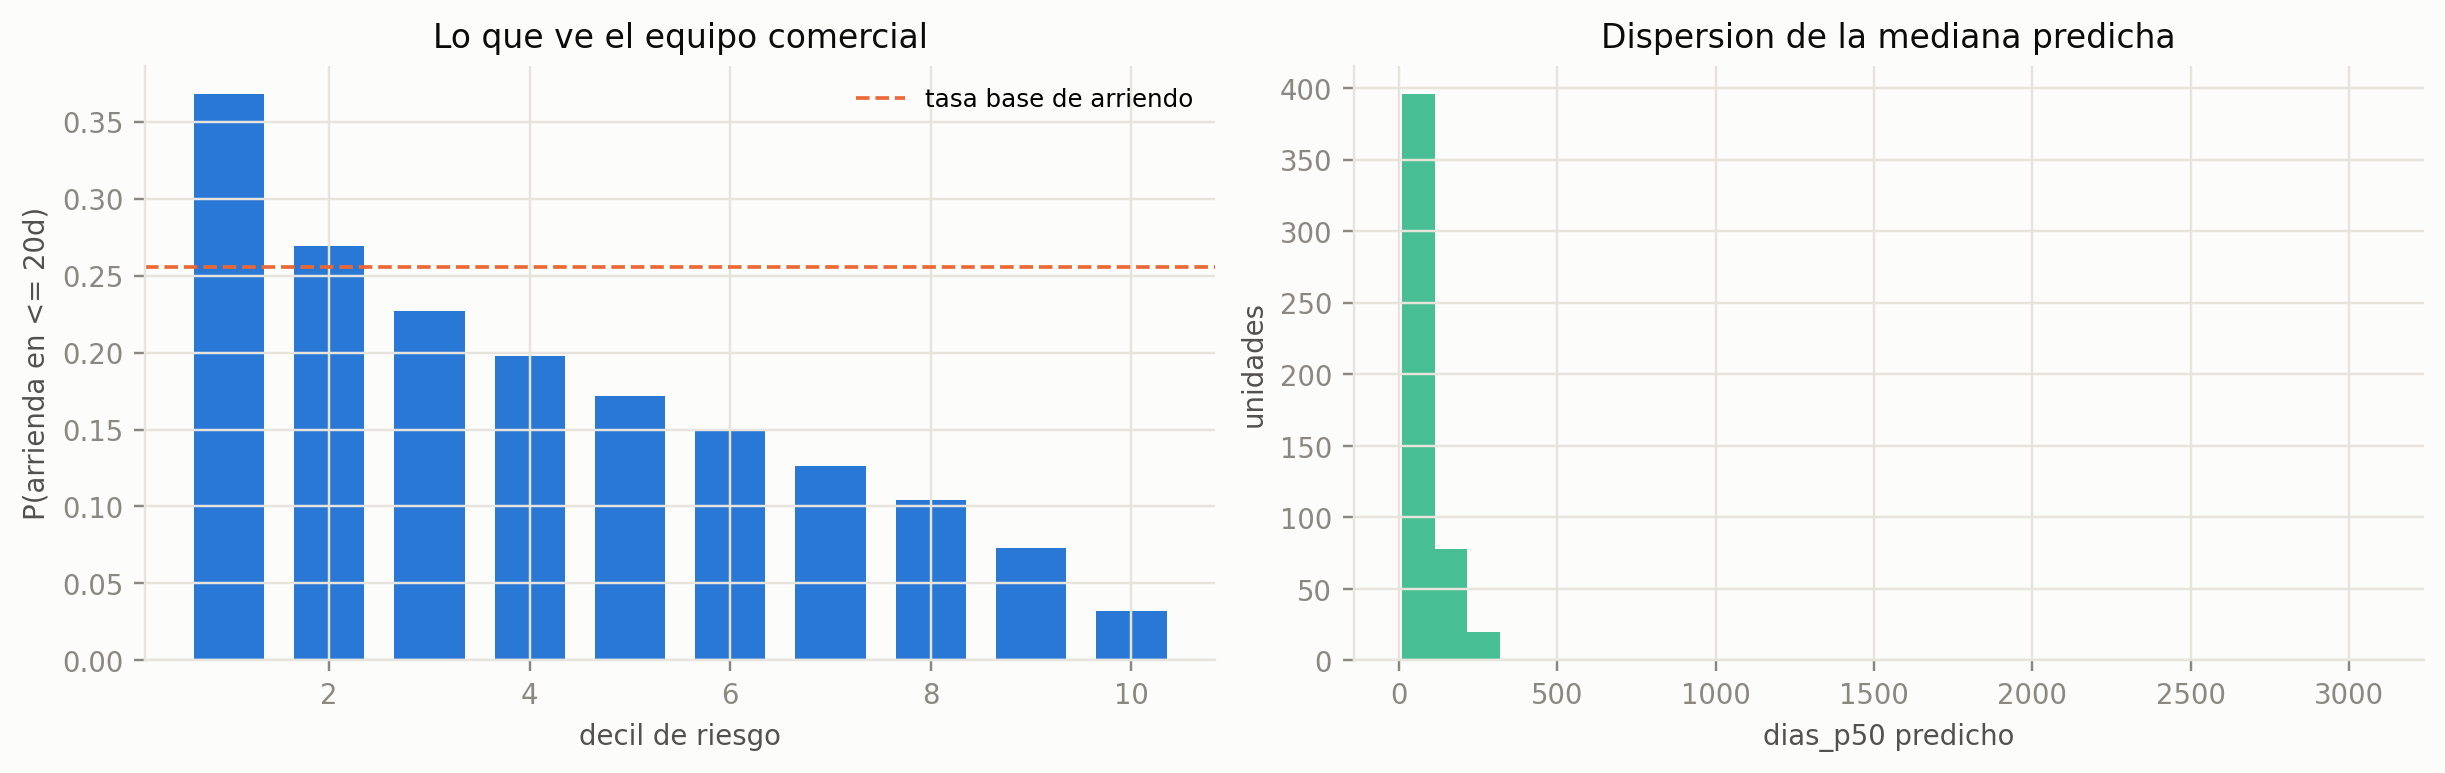

In [101]:
# Como se ve la cola de trabajo que recibe el equipo comercial.
q = muestra.groupby("decil_riesgo").agg(
    n=("p_rapido_20d", "size"), p_media=("p_rapido_20d", "mean"),
    dias_p50_medio=("dias_p50", "median")).round(3)
display(q)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), constrained_layout=True)
axes[0].bar(q.index, q["p_media"], color=AZUL, width=0.7)
axes[0].axhline(np.nanmean(target_binario(D, H_REPORTE)), color=NARANJA,
                lw=1.2, ls="--", label="tasa base de arriendo")
axes[0].set_xlabel("decil de riesgo")
axes[0].set_ylabel(f"P(arrienda en <= {H_REPORTE}d)")
axes[0].set_title("Lo que ve el equipo comercial")
axes[0].legend(frameon=False, fontsize=8)

axes[1].hist(muestra["dias_p50"], bins=30, color=AQUA, alpha=0.8)
axes[1].set_xlabel("dias_p50 predicho"); axes[1].set_ylabel("unidades")
axes[1].set_title("Dispersion de la mediana predicha")
plt.show()

## Paso 9 · Monitoreo y reentrenamiento

**Funcionamiento.** La validación forward de este cuaderno **es** el backtest de producción: no
hay que construir nada aparte. Cada mes que cierra se convierte en un fold de test nuevo.

**Reglas operativas:**

- **Reentrenar mensualmente.** La deriva está medida: las visitas de la primera semana se
  mueven entre 4,7 y 13,3 por cohorte. Un modelo congelado se degrada.
- **Alarma automática** si el AUC de la cohorte nueva cae bajo el baseline de la tabla dinámica
  (0,586). Si eso pasa dos meses seguidos, el modelo dejó de aportar.
- **Revisar la calibración cada vez.** Es lo primero que se rompe cuando cambia la mezcla de
  cartera, y se arregla reajustando Platt sin tocar el modelo.
- **Cobertura.** ~9% de las unidades que llegan a LPA no tienen historial de precio y no se
  pueden puntuar. Necesitan una regla de fallback explícita, no un `NaN` silencioso.

**Interpretación del panel.** Si el AUC por cohorte oscila sin tendencia, el modelo está sano.
Una caída sostenida es deriva de concepto, no ruido, y obliga a revisar features. Un salto en
`sd(gap_hedonico)` indica que cambió la política de precios y que el referente hay que
reajustarlo antes que el modelo.

,n,AUC,Brier,Calib_slope,tasa_real,p_media
cohorte,,,,,,
2026-01,242,0.619,0.178,0.310,0.231,0.165
2026-02,260,0.766,0.161,0.876,0.250,0.172
2026-03,351,0.680,0.137,0.747,0.182,0.207
2026-04,365,0.788,0.100,0.659,0.112,0.162
2026-05,260,0.771,0.107,0.981,0.150,0.121
2026-06,283,0.756,0.105,0.970,0.134,0.113
2026-07,267,0.670,0.106,0.569,0.127,0.124


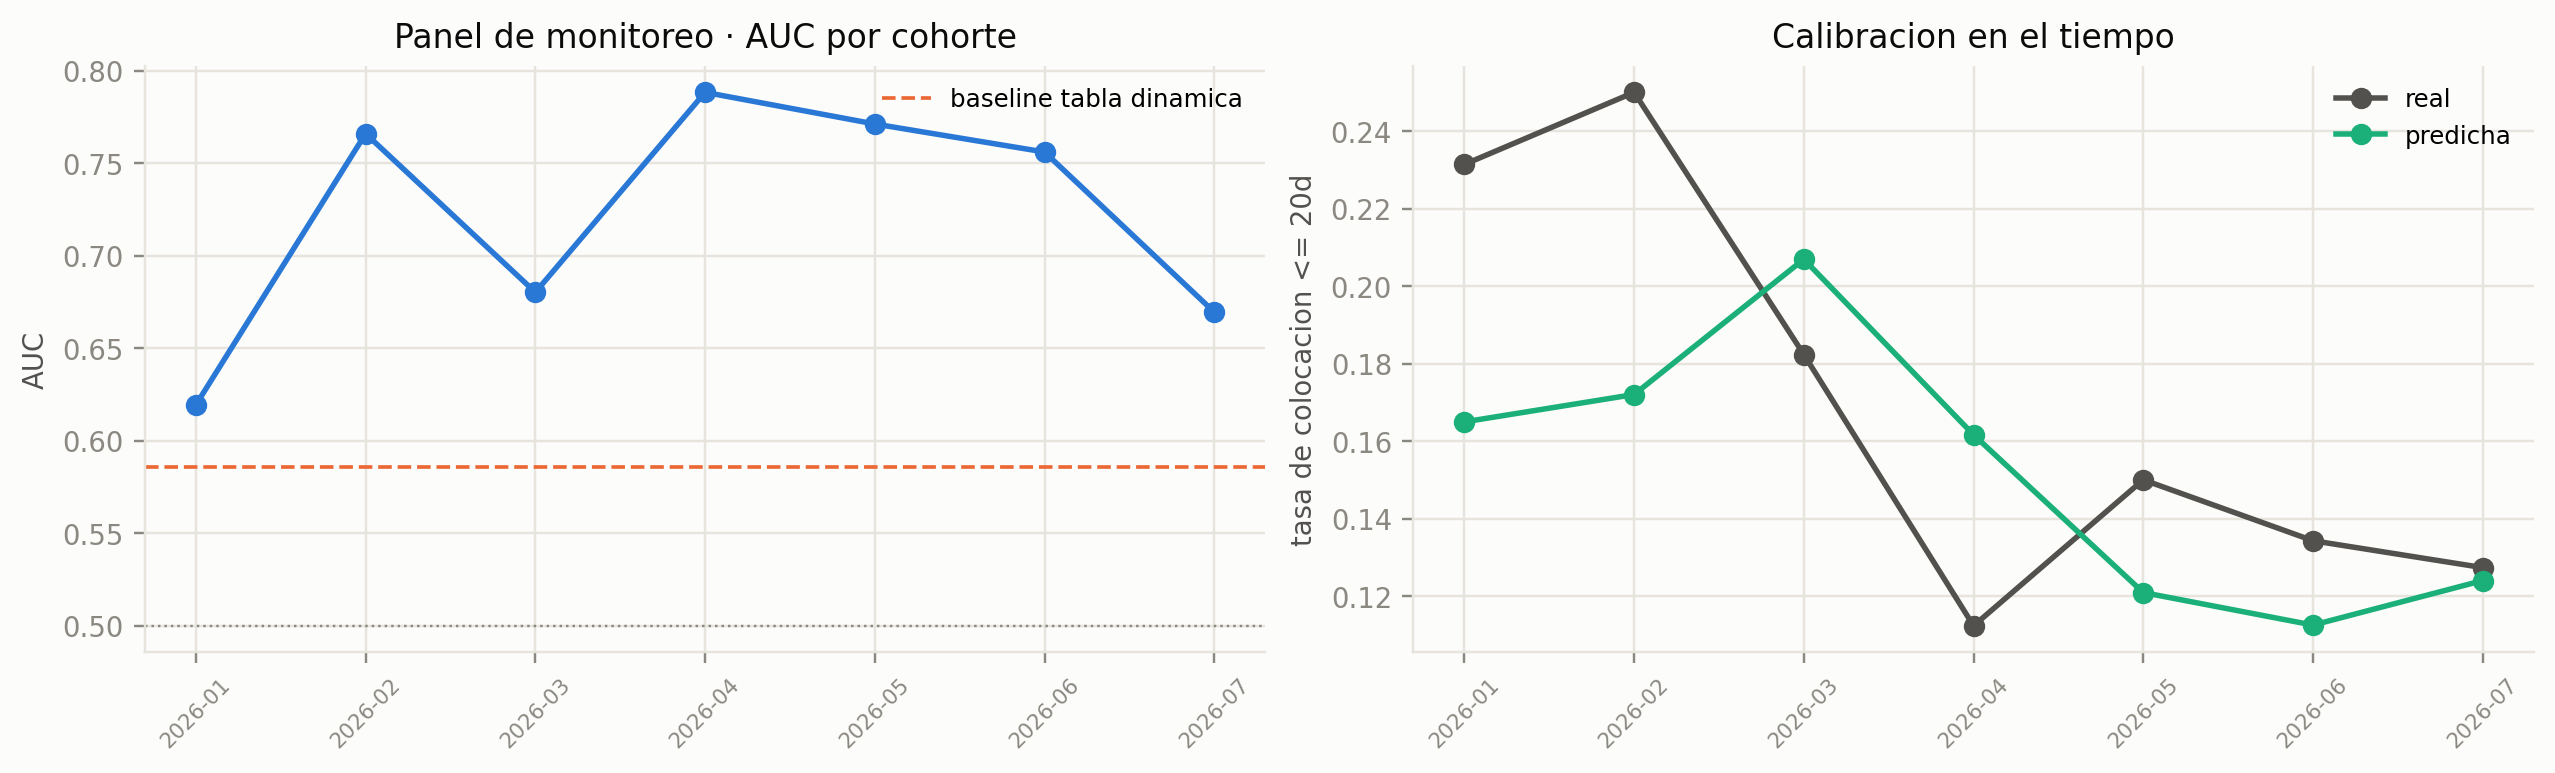

Cohortes bajo el baseline: 0 de 7


In [102]:
dd = pred_mejor["datos"].iloc[pred_mejor["idx"]]
j = REJILLA_H.index(H_REPORTE)
p = np.clip(pred_mejor["cif"][:, j], 1e-6, 1 - 1e-6)
y = target_binario(dd, H_REPORTE)
coh = dd["cohorte_lpa"].to_numpy()

filas = []
for c in sorted(set(coh)):
    m = (coh == c) & np.isfinite(y)
    if m.sum() < 30 or len(np.unique(y[m])) < 2:
        continue
    filas.append({"cohorte": c, "n": int(m.sum()),
                  "AUC": roc_auc_score(y[m], p[m]),
                  "Brier": brier_score_loss(y[m], p[m]),
                  "Calib_slope": pendiente(y[m], p[m]),
                  "tasa_real": float(y[m].mean()), "p_media": float(p[m].mean())})
mon = pd.DataFrame(filas).set_index("cohorte")
display(mon.round(3))

BASE_AUC = 0.586
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4), constrained_layout=True)
axes[0].plot(range(len(mon)), mon["AUC"], "o-", color=AZUL, lw=1.8)
axes[0].axhline(BASE_AUC, color=NARANJA, lw=1.2, ls="--", label="baseline tabla dinamica")
axes[0].axhline(0.5, color=INK_MUTED, lw=0.8, ls=":")
axes[0].set_xticks(range(len(mon))); axes[0].set_xticklabels(mon.index, rotation=45, fontsize=7)
axes[0].set_ylabel("AUC"); axes[0].set_title("Panel de monitoreo · AUC por cohorte")
axes[0].legend(frameon=False, fontsize=8)

axes[1].plot(range(len(mon)), mon["tasa_real"], "o-", color=INK_SOFT, lw=1.8, label="real")
axes[1].plot(range(len(mon)), mon["p_media"], "o-", color=AQUA, lw=1.8, label="predicha")
axes[1].set_xticks(range(len(mon))); axes[1].set_xticklabels(mon.index, rotation=45, fontsize=7)
axes[1].set_ylabel(f"tasa de colocacion <= {H_REPORTE}d")
axes[1].set_title("Calibracion en el tiempo"); axes[1].legend(frameon=False, fontsize=8)
plt.show()

bajo = mon[mon["AUC"] < BASE_AUC]
print(f"Cohortes bajo el baseline: {len(bajo)} de {len(mon)}"
      + (f" -> {list(bajo.index)}" if len(bajo) else ""))

## Cómo se usa, y qué significa

**Funcionamiento.** El modelo estima, para cada unidad, la tasa a la que se arrienda en función
de sus atributos, su ubicación, el historial de su edificio y **cuán cara está respecto de lo
que sus propios atributos justifican**. De esa tasa sale la curva completa de probabilidad de
colocación y, en el modo día 7, se le suma la demanda efectivamente observada en la primera
semana.

**Inferencia.** Todo lo que se reporta viene de validación *forward* por cohorte: entrenar con
el pasado, predecir el mes siguiente. Las probabilidades están recalibradas con Platt estimado
también hacia adelante. El AUC de una CV aleatoria sería ~0,06 más alto y sería mentira.

**Interpretación — lo que el número significa.** `p_rapido_20d = 0,28` quiere decir que, entre
las unidades con ese score, alrededor de 28 de cada 100 se colocan dentro de los 20 días —y las
otras 72 no—. El decil de riesgo va al revés que la probabilidad: el decil 10 concentra las
más lentas: intervenir ahí en lugar de al azar reduce ~4× las
intervenciones que caen sobre unidades que se habrían arrendado igual.

**Lo que el modelo NO es.**

No predice días. El error absoluto mediano es ~20 días contra una mediana de 29. Se entrega
probabilidad y decil.

Y para un **edificio nuevo sin historial**, el target encoding cae al promedio global: el modelo
es más débil justo donde más se lo querría. Conviene medir su desempeño en esos casos aparte.

## Paso 10 · Regresor generado: errores estándar y atenuación

El `gap_hedonico` no es un dato observado, es el **residuo de un modelo que estimamos nosotros**
con la misma muestra. Eso rompe dos cosas distintas, y hay que tratarlas por separado porque
tienen remedios distintos:

| | qué se rompe | remedio | está acá |
|---|---|---|---|
| **(a) Inferencia** | la varianza de la 2ª etapa ignora que la 1ª también se estimó | bootstrap de las dos etapas (o Murphy–Topel) | sí |
| **(b) Sesgo** | error de medición en el regresor → atenuación | razón de confiabilidad / SIMEX / VI | sí, parcial |

**El bootstrap no corrige (b).** Un bootstrap reproduce en cada réplica el sesgo que tenga el
estimador: si α̂ está atenuado, las 200 réplicas están atenuadas y el resultado es un intervalo
angosto alrededor del número equivocado. Pagan (1984) es un resultado sobre la **varianza**, no
sobre el punto. Allen, Rutherford & Thomson (2009) bootstrapean y no corrigen la atenuación.

### (a) Bootstrap de dos etapas

Se corren dos bootstraps sobre **las mismas remuestras**, y la comparación entre ambos es el
resultado:

| | primera etapa | resto del pipeline |
|---|---|---|
| **ingenuo** | congelada (el gap se calcula una vez y se arrastra como dato) | se reajusta |
| **completo** | se reajusta en cada réplica | se reajusta |

El cociente `se_completo / se_ingenuo` es el factor por el que se subestima la incertidumbre al
tratar el gap como observado. Las remuestras son **por edificio, no por fila**: dos unidades del
mismo edificio comparten calidad no observada, conserje y la misma decisión de precio.

### (b) Atenuación, y cómo la mide el mismo bootstrap

Sea $p^{*}$ el precio hedónico poblacional y $\hat p$ nuestra estimación. El gap verdadero es
$g=\log p-\log p^{*}$; el que usamos es

$$\hat g \;=\; \log p-\log\hat p \;=\; g-\xi,\qquad \xi=\log\hat p-\log p^{*},$$

que es error de medición **en la variable explicativa**. Con $\xi \perp g$,

$$\operatorname{plim}\hat\alpha \;=\; \alpha\cdot\underbrace{\frac{\operatorname{Var}(g)}{\operatorname{Var}(g)+\operatorname{Var}(\xi)}}_{\lambda\ \text{(razón de confiabilidad)}}\;<\;\alpha .$$

El problema práctico es que $\operatorname{Var}(\xi)$ **no se identifica con el residuo del
hedónico**, porque ese residuo *es* $\hat g$ y ya trae las dos varianzas juntas:
$\operatorname{Var}(\hat g)=\operatorname{Var}(g)+\operatorname{Var}(\xi)$.

La salida usa la misma maquinaria del bootstrap. Para una unidad **fija** $i$, la dispersión de
$\hat g_i^{(b)}$ a través de las réplicas aísla la variabilidad de la primera etapa, porque
$g_i$ no cambia entre réplicas:

$$\hat g_i^{(b)}-\hat g_i=-\bigl(\log\hat p^{(b)}(x_i)-\log\hat p(x_i)\bigr)
\;\Longrightarrow\;
\widehat{\operatorname{Var}}(\xi)=\frac{1}{n}\sum_i \operatorname{Var}_b\!\left(\hat g_i^{(b)}\right).$$

Con eso, $\hat\lambda = 1-\widehat{\operatorname{Var}}(\xi)/\operatorname{Var}(\hat g)$ y el
coeficiente corregido es $\hat\alpha/\hat\lambda$.

**Dos límites de esta corrección, y son importantes.**

1. El bootstrap mide el error de **estimación** de $\hat p$, no el de **especificación**. Si el
   hedónico está mal especificado, $\hat p$ es sesgado para $p^{*}$ y ese componente no aparece
   en la dispersión entre réplicas. Entonces $\widehat{\operatorname{Var}}(\xi)$ es una
   subestimación, $\hat\lambda$ una sobrestimación, y $\hat\alpha/\hat\lambda$ **sigue siendo una
   cota inferior** — nada más que menos conservadora que $\hat\alpha$.
2. Corrige la atenuación por medición, **no la endogeneidad**. Quien fija el precio observa cosas
   que el modelo no ve, y $\operatorname{Cov}(g,u)<0$ bajo las dos historias de pricing plausibles
   del anexo. Ese sesgo empuja en la misma dirección y queda vivo.

Los coeficientes están en escala AFT: $\log T=X\beta+\sigma\varepsilon$, así que **β positivo =
más días = más lento**. Para el gap, que ya viene en logaritmos, β es una elasticidad y es
directamente comparable con el **+0,444** de Allen et al. (ellos reportan −0,444 sobre el ratio
invertido).


In [103]:
# La celda mas lenta del cuaderno: 2 x B_BOOT ajustes completos del pipeline.
# Con el gradiente analitico del AFT el costo por replica lo domina el hedonico
# GBM, no la optimizacion: del orden de 0,3-0,5s con la muestra real, o sea unos
# 3 minutos para B=200. Imprime el ritmo medido tras la quinta replica.
B_BOOT = 200

# --------------------------------------------------------------------------
# GUARDA DE KERNEL. Esta celda es inutilizable con la version de ajustar_aft
# anterior al gradiente analitico: son ~50 evaluaciones de la verosimilitud por
# iteracion en vez de 1,6, o sea 45 minutos en lugar de 3. Y Jupyter no avisa:
# si el archivo cambio pero la celda que define la funcion no se volvio a
# ejecutar, el kernel sigue usando la definicion vieja.
if getattr(ajustar_aft, "gradiente", None) != "analitico":
    raise RuntimeError(
        "ajustar_aft es la version SIN gradiente analitico.\n"
        "El kernel tiene definiciones viejas en memoria. Reinicia el kernel y\n"
        "corre todo el cuaderno (Restart Kernel and Run All), o al menos vuelve\n"
        "a ejecutar la celda de imports y la celda que define ajustar_aft antes\n"
        "de esta. Tal como esta, esta celda tardaria ~45 minutos por bootstrap.")

# La inferencia se hace sobre la especificacion que CONTIENE el parametro, no
# sobre la que gano por AUC. Que el gap no mejore la discriminacion no borra la
# pregunta "cuanto vale su coeficiente y con que precision": la vuelve mas
# interesante, porque esto es justo lo que dice si ese aporte se distingue de
# cero. Modo y landmark si se heredan del modelo desplegado.
CFG_BOOT = {**CFG_PROD, "con_gap": True}
print(f"Configuracion desplegada   : {CFG_PROD}")
print(f"Configuracion del bootstrap: {CFG_BOOT}"
      + ("   <- gap forzado para poder hacerle inferencia"
         if not CFG_PROD["con_gap"] else ""))

BASE_BOOT = (L if CFG_BOOT["land"] else D).reset_index(drop=True)
_ref_full = PrecioReferencia(motor=MOTOR_REF).fit(BASE_BOOT)
BASE_BOOT["gap_dado"] = _ref_full.transform(BASE_BOOT).ravel()
VAR_GAP = float(np.var(BASE_BOOT["gap_dado"], ddof=1))
print(f"\nGap de la muestra completa: sd = {np.sqrt(VAR_GAP):.4f}  (n = {len(BASE_BOOT):,})")


def diseno_gap_dado(modo="d0"):
    '''Igual que diseno(), pero el gap entra como columna ya calculada en vez de
    reestimarse. Todo lo demas se reajusta: asi la unica diferencia entre los dos
    bootstraps es la primera etapa, y las dos matrices tienen las mismas columnas.'''
    num = FEAT_NUM_D0 + (FEAT_D7 if modo == "d7" else [])
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", _ohe())]), FEAT_CAT),
        ("te", Pipeline([("te", TargetEncoderJerarquico(CADENA_GEO, salida=FEAT_HI,
                                                        m=M_SHRINK, semilla=SEMILLA)),
                         ("sc", StandardScaler())]), CADENA_GEO),
        ("gap", StandardScaler(), ["gap_dado"]),
    ], remainder="drop")


def _ajuste_boot(datos, congelado):
    y = target_binario(datos, H_REPORTE)
    pre = (diseno_gap_dado(CFG_BOOT["modo"]) if congelado
           else diseno(CFG_BOOT["modo"], True))
    X = pre.fit_transform(datos, y)
    mod = ajustar_aft(X, np.log(datos["dias_obs"].clip(lower=1).to_numpy(float)),
                      datos["evento_arriendo"].to_numpy(int))
    nombres = ["const"] + [str(n) for n in pre.get_feature_names_out()]
    if congelado:
        nombres = [n.replace("gap__gap_dado", "gap__gap_hedonico") for n in nombres]
    return nombres, mod["beta"], mod["sigma"], mod["conv"], pre


def _remuestra_por_edificio(datos, rng):
    g = datos.groupby("grupo_edificio").indices
    claves = list(g.keys())
    elegidas = rng.choice(len(claves), size=len(claves), replace=True)
    idx = np.concatenate([g[claves[i]] for i in elegidas])
    return datos.iloc[idx].reset_index(drop=True)


def correr_bootstrap(congelado, B, semilla=SEMILLA):
    '''Devuelve (betas, sigmas, fallos, G). G solo en el bootstrap completo: es la
    matriz B x n del gap recalculado sobre las MISMAS unidades originales con el
    hedonico de cada replica. Su varianza por columna estima Var(xi).'''
    rng = np.random.default_rng(semilla)      # mismas remuestras en ambos bootstraps
    filas, sigmas, gaps, fallos = [], [], [], 0
    t0 = time.time()
    for b in range(B):
        bt = _remuestra_por_edificio(BASE_BOOT, rng)
        try:
            nom, beta, sg, conv, pre = _ajuste_boot(bt, congelado)
            if not conv:
                fallos += 1
                continue
            if not congelado:
                ref_b = pre.named_transformers_["gap"].named_steps["ref"]
                gaps.append(ref_b.transform(BASE_BOOT).ravel())
        except Exception:
            fallos += 1
            continue
        filas.append(pd.Series(beta, index=nom))
        sigmas.append(sg)
        if b == 4:
            print(f"    ritmo {(time.time() - t0) / 5:.1f}s/replica -> "
                  f"~{(time.time() - t0) / 5 * B / 60:.1f} min")
    G = np.vstack(gaps) if gaps else None
    return pd.DataFrame(filas), np.array(sigmas), fallos, G


NOM0, BETA0, SIGMA0, _, _ = _ajuste_boot(BASE_BOOT, congelado=False)
punto = pd.Series(BETA0, index=NOM0)
print(f"Ajuste en la muestra completa: {len(punto)} coeficientes · sigma {SIGMA0:.3f}")

print(f"\nBootstrap INGENUO  (primera etapa congelada), B={B_BOOT}")
bi, sg_i, f_i, _ = correr_bootstrap(True, B_BOOT)
print(f"    {len(bi)} replicas utiles, {f_i} descartadas")

print(f"\nBootstrap COMPLETO (dos etapas), B={B_BOOT}")
bc, sg_c, f_c, G_BOOT = correr_bootstrap(False, B_BOOT)
print(f"    {len(bc)} replicas utiles, {f_c} descartadas")


Configuracion desplegada   : {'modo': 'd7', 'con_gap': False, 'land': True}
Configuracion del bootstrap: {'modo': 'd7', 'con_gap': True, 'land': True}   <- gap forzado para poder hacerle inferencia

Gap de la muestra completa: sd = 0.1143  (n = 3,531)
Ajuste en la muestra completa: 48 coeficientes · sigma 0.990

Bootstrap INGENUO  (primera etapa congelada), B=200
    ritmo 0.1s/replica -> ~0.5 min
    200 replicas utiles, 0 descartadas

Bootstrap COMPLETO (dos etapas), B=200
    ritmo 0.3s/replica -> ~1.0 min


c:\Users\assetplan\Desktop\Códigos\arriendo\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\assetplan\Desktop\Códigos\arriendo\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\assetplan\Desktop\Códigos\arriendo\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\assetplan\Desktop\Códigos\arriendo\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown catego

    200 replicas utiles, 0 descartadas


(a) Los 15 coeficientes mas fuertes  ·  escala AFT: + = mas dias = mas lento


,coef,se_ingenuo,se_completo,inflacion,t_completo,ic95_inf,ic95_sup,signif,inestable
const,4.230,0.159,0.158,0.993,26.817,3.925,4.530,si,
num__d0_7_leads,-0.144,0.021,0.021,1.002,-6.900,-0.175,-0.092,si,
num__ggcc_falta,0.245,0.041,0.041,0.998,5.951,0.143,0.329,si,
num__d0_7_reservas,0.192,0.033,0.033,0.998,5.883,0.124,0.248,si,
num__piso_es_cero,0.143,0.029,0.029,0.985,5.005,0.074,0.188,si,
num__log_visitas_d0_7,-0.148,0.034,0.033,0.999,-4.441,-0.222,-0.096,si,
num__mes_sin,0.115,0.030,0.031,1.004,3.740,0.055,0.171,si,
num__tiene_lead_d0_7,-0.100,0.032,0.032,0.999,-3.163,-0.139,-0.018,si,
num__acepta_mascotas,-0.079,0.026,0.026,0.981,-3.070,-0.114,-0.019,si,
te__grupo_edificio_te,-0.292,0.096,0.096,0.993,-3.063,-0.685,-0.333,si,!


Inflacion mediana del error estandar por regresor generado: 0.992x
[!] 1 coeficientes con el punto fuera de su propio IC (no identificados): ['grupo_edificio_te']
sigma: punto 0.990 · IC95 [0.910, 1.010]

(b) Correccion de atenuacion
  Var(gap)  observado, entre unidades   0.013075   sd 0.1143
  Var(xi)   estimado, entre replicas    0.001459   sd 0.0382
  lambda = 1 - Var(xi)/Var(gap)      =  0.8884

  gap_hedonico   alpha        +0.0642   IC95 [-0.1272, +0.1995]
                 alpha/lambda +0.0722   IC95 [-0.1431, +0.2246]
                 se ingenuo 0.1030 -> completo 0.0876  (0.850x)

  Referencia: Allen, Rutherford & Thomson (2009), AFT Weibull, n=20.131: +0,444
  Sigue siendo COTA INFERIOR: lambda solo captura el error de estimacion
  de la primera etapa, no el de especificacion, y la endogeneidad del
  precio queda sin corregir y empuja en la misma direccion.


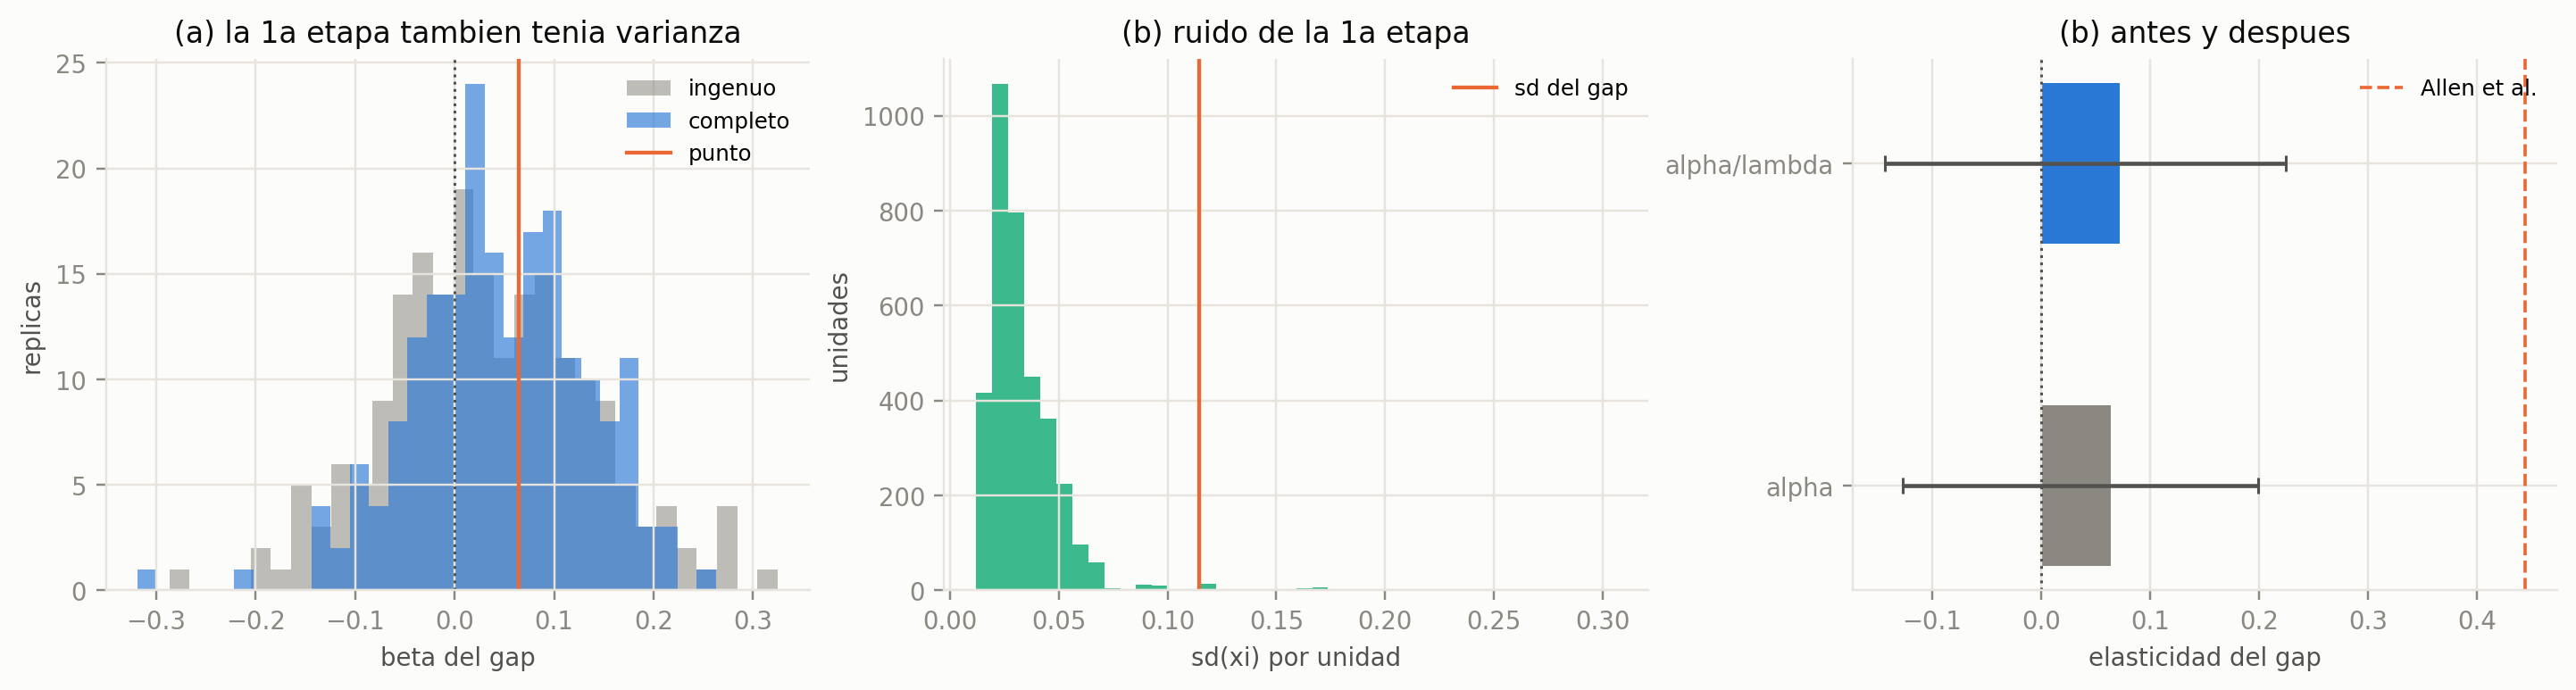


Guardado en boot_resultados para el anexo econometrico.


In [104]:
# --------------------------------------------------------------------------
# (a) Errores estandar: cuanto se subestimaban
# --------------------------------------------------------------------------
comunes = [c for c in punto.index if c in bi.columns and c in bc.columns]
MIN_REP = 0.80        # un nivel ausente en mas del 20% de las replicas no se reporta
tab = pd.DataFrame({
    "coef":        punto[comunes],
    "presencia":   bc[comunes].notna().mean(),
    "se_ingenuo":  bi[comunes].std(),
    "se_completo": bc[comunes].std(),
    "sesgo_boot":  bc[comunes].mean() - punto[comunes],
    "ic95_inf":    bc[comunes].quantile(0.025),
    "ic95_sup":    bc[comunes].quantile(0.975),
})
tab = tab[tab["presencia"] >= MIN_REP].copy()
tab["inflacion"]  = tab["se_completo"] / tab["se_ingenuo"].replace(0, np.nan)
tab["t_completo"] = tab["coef"] / tab["se_completo"].replace(0, np.nan)
tab["signif"] = np.where((tab["ic95_inf"] > 0) | (tab["ic95_sup"] < 0), "si", "")
# Control de cordura: si el punto cae FUERA de su propio intervalo bootstrap ese
# coeficiente no esta identificado (colinealidad con el intercepto o con otro
# nivel) y su error estandar no significa nada, por chico que se vea.
tab["inestable"] = np.where((punto[tab.index] < tab["ic95_inf"])
                            | (punto[tab.index] > tab["ic95_sup"]), "!", "")

orden = tab.reindex(tab["t_completo"].abs().sort_values(ascending=False).index)
print("=" * 78)
print("(a) Los 15 coeficientes mas fuertes  ·  escala AFT: + = mas dias = mas lento")
display(orden[["coef", "se_ingenuo", "se_completo", "inflacion", "t_completo",
               "ic95_inf", "ic95_sup", "signif", "inestable"]].head(15).round(4))
print(f"Inflacion mediana del error estandar por regresor generado: "
      f"{tab['inflacion'].median():.3f}x")
_ines = tab.index[tab["inestable"] == "!"].tolist()
if _ines:
    print(f"[!] {len(_ines)} coeficientes con el punto fuera de su propio IC "
          f"(no identificados): {[n.split('__')[-1] for n in _ines][:6]}")
print(f"sigma: punto {SIGMA0:.3f} · IC95 "
      f"[{np.quantile(sg_c, 0.025):.3f}, {np.quantile(sg_c, 0.975):.3f}]")

# --------------------------------------------------------------------------
# (b) Atenuacion: razon de confiabilidad medida con la dispersion del bootstrap
# --------------------------------------------------------------------------
GAP = next((c for c in tab.index if "gap_hedonico" in c), None)
LAMBDA = np.nan
if G_BOOT is None or GAP is None:
    print("\n[!] sin matriz de gaps o sin coeficiente de gap: no hay correccion que hacer.")
else:
    var_xi_i = G_BOOT.var(axis=0, ddof=1)          # varianza por UNIDAD entre replicas
    VAR_XI = float(np.mean(var_xi_i))
    LAMBDA = 1.0 - VAR_XI / VAR_GAP
    a = float(tab.loc[GAP, "coef"])
    se = float(tab.loc[GAP, "se_completo"])
    lo, hi = float(tab.loc[GAP, "ic95_inf"]), float(tab.loc[GAP, "ic95_sup"])

    print("\n" + "=" * 78)
    print("(b) Correccion de atenuacion")
    print(f"  Var(gap)  observado, entre unidades   {VAR_GAP:.6f}   sd {np.sqrt(VAR_GAP):.4f}")
    print(f"  Var(xi)   estimado, entre replicas    {VAR_XI:.6f}   sd {np.sqrt(VAR_XI):.4f}")
    print(f"  lambda = 1 - Var(xi)/Var(gap)      =  {LAMBDA:.4f}")
    if not (0 < LAMBDA <= 1):
        print("  [!] lambda fuera de (0,1]: la primera etapa es mas ruidosa que la senal")
        print("      que pretende medir. No se aplica la correccion.")
    else:
        print(f"\n  gap_hedonico   alpha        {a:+.4f}   IC95 [{lo:+.4f}, {hi:+.4f}]")
        print(f"                 alpha/lambda {a / LAMBDA:+.4f}   IC95 "
              f"[{lo / LAMBDA:+.4f}, {hi / LAMBDA:+.4f}]")
        print(f"                 se ingenuo {tab.loc[GAP, 'se_ingenuo']:.4f} -> "
              f"completo {se:.4f}  ({tab.loc[GAP, 'inflacion']:.3f}x)")
        print("\n  Referencia: Allen, Rutherford & Thomson (2009), AFT Weibull, "
              "n=20.131: +0,444")
        print("  Sigue siendo COTA INFERIOR: lambda solo captura el error de estimacion")
        print("  de la primera etapa, no el de especificacion, y la endogeneidad del")
        print("  precio queda sin corregir y empuja en la misma direccion.")

    fig, ax = plt.subplots(1, 3, figsize=(13, 3.4), constrained_layout=True)
    ax[0].hist(bi[GAP].dropna(), bins=30, color=INK_MUTED, alpha=0.55, label="ingenuo")
    ax[0].hist(bc[GAP].dropna(), bins=30, color=AZUL, alpha=0.65, label="completo")
    ax[0].axvline(a, color=NARANJA, lw=1.4, label="punto")
    ax[0].axvline(0, color=INK_SOFT, lw=1, ls=":")
    ax[0].set_xlabel("beta del gap")
    ax[0].set_ylabel("replicas")
    ax[0].set_title("(a) la 1a etapa tambien tenia varianza")
    ax[0].legend(frameon=False, fontsize=8)

    ax[1].hist(np.sqrt(var_xi_i), bins=40, color=AQUA, alpha=0.85)
    ax[1].axvline(np.sqrt(VAR_GAP), color=NARANJA, lw=1.4, label="sd del gap")
    ax[1].set_xlabel("sd(xi) por unidad")
    ax[1].set_ylabel("unidades")
    ax[1].set_title("(b) ruido de la 1a etapa")
    ax[1].legend(frameon=False, fontsize=8)

    if 0 < LAMBDA <= 1:
        ax[2].barh([0, 1], [a, a / LAMBDA], color=[INK_MUTED, AZUL], height=0.5)
        ax[2].errorbar([a, a / LAMBDA], [0, 1],
                       xerr=[[a - lo, (a - lo) / LAMBDA], [hi - a, (hi - a) / LAMBDA]],
                       fmt="none", ecolor=INK_SOFT, capsize=3)
        ax[2].axvline(0, color=INK_SOFT, lw=1, ls=":")
        ax[2].axvline(0.444, color=NARANJA, lw=1.2, ls="--", label="Allen et al.")
        ax[2].set_yticks([0, 1])
        ax[2].set_yticklabels(["alpha", "alpha/lambda"])
        ax[2].set_xlabel("elasticidad del gap")
        ax[2].set_title("(b) antes y despues")
        ax[2].legend(frameon=False, fontsize=8)
    plt.show()

boot_resultados = {"punto": punto, "ingenuo": bi, "completo": bc, "tabla": tab,
                   "sigma_completo": sg_c, "lambda": LAMBDA, "var_gap": VAR_GAP,
                   "gaps_replicas": G_BOOT}
print("\nGuardado en boot_resultados para el anexo econometrico.")


## Paso 11 · Puntuar una unidad nueva

**Funcionamiento.** Todo lo anterior evalúa el modelo sobre unidades que ya ocurrieron. Esta
sección lo usa al revés: se describen las características de una unidad que **todavía no se
publica** y el modelo devuelve su curva de arriendo. Se completa la ficha con la mediana (o la
moda) del entrenamiento para los campos que no se entreguen, se puntúa con el mismo
`scorer` del Paso 8 —el mismo precio de referencia, el mismo diseño de features, la misma
recalibración— y se reporta el resultado junto con **de dónde salió cada dato**, porque una
predicción sostenida por ocho valores por defecto no vale lo mismo que una sostenida por la
ficha completa.

**Inferencia.** Salen cuatro números y ninguno significa lo mismo:

- `p_rapido_20d` es la probabilidad de que la unidad **se arriende dentro** de los 20 días.
  Está recalibrada, así que es una probabilidad y no un puntaje: si el modelo dice 0,30 a un
  grupo de unidades, alrededor de 30 de cada 100 deberían efectivamente colocarse en ese plazo.
- `decil` sigue ordenando por **riesgo**, no por probabilidad: 1 es la más rápida y 10 la más
  lenta. Como la probabilidad ahora crece con la velocidad, el decil va al revés que ella. Y
  es una posición **dentro de la última cohorte real**, no una escala absoluta: decil 9 no dice
  "es mala", dice "de las unidades que publicamos el mes pasado, esta está entre el 10% más
  lento".
- `dias_p50` es la mediana predicha. `dias_p10`–`dias_p90` es el intervalo del 80%, y con
  σ ≈ 1,3 ese intervalo abarca típicamente un factor de 10x. **Esa es la razón por la que
  `dias_p50` no se publica solo**: el modelo ordena bien y pronostica mal el día exacto.
- `precio_sugerido` es lo que el hedónico esperaría cobrar por una unidad con estos atributos,
  en esta comuna, en este edificio. El `gap` es la distancia entre lo que se quiere cobrar y eso.

**Interpretación.** En tu corrida ganó **día 7 · con demanda + gap** (AUC@20 0,722 vs. 0,681
del día 0), y ese resultado manda sobre cómo se lee esta sección. El aporte de la demanda
observada entre el día 0 y el 7 es **+0,094 de AUC**; el del gap hedónico, dentro de ese mismo
modelo, **+0,003**. O sea: el modelo desplegado **no es una herramienta de pricing, es una
alerta**. Lo que sabe es que una unidad que en su primera semana no generó visitas se va a
demorar, y eso lo sabe muy bien.

Por eso hay dos curvas al final y no una:

- **Curva de demanda** — cómo cambia `p_rapido_20d` según las visitas de la primera semana. Es
  la variable que el modelo efectivamente usa, y sirve para leer la alerta: cuántas visitas le
  faltaron a esta unidad para salir de la zona roja. Debe subir con las visitas.
- **Curva de precio** — cómo cambia al mover el precio publicado. **Va a salir casi plana**, y
  eso no es un error del código: es el hallazgo. El gap que construimos en casa aporta 0,003
  donde el gap del ML ex-ante aportaba 0,052. Lo que el modelo de pricing sabía no está en los
  atributos de la unidad, y sin ese insumo el precio deja de ser una palanca medible. Dejo la
  curva porque el día que exista un precio de referencia ex-ante de verdad, esta es la celda
  que hay que volver a mirar.

Dos advertencias sobre la curva de precio, y son serias:

1. Es una asociación condicional, no un experimento. Quien fija el precio observa cosas que el
   modelo no ve (el estado real del departamento, la urgencia del propietario), y por el
   argumento de endogeneidad del anexo econométrico ese sesgo **atenúa**: la pendiente estimada
   es una **cota inferior** del efecto real de bajar el precio.
2. Es *ceteris paribus* dentro del soporte de los datos. Fuera de la banda de ±20% es
   extrapolación y el aviso lo dice.

Y una sobre la de demanda, que es la más importante de todas: **las visitas no causan el
arriendo, lo anticipan**. Mover el número de visitas en la celda no "arregla" la unidad; lo que
la curva dice es cuánta señal trae cada nivel de interés observado. El uso legítimo es priorizar
—a quién llamar el lunes de la segunda semana—, no prometer que forzar visitas acorta el
arriendo.


In [105]:
from datetime import date

# --------------------------------------------------------------------------
# 1. La lista de comunas sale del scorer, no de un parche
# --------------------------------------------------------------------------
# comuna_g depende de la MUESTRA, no de la fila: con un solo registro ninguna
# comuna alcanza MIN_OBS y todas caerian en "Otras". La lista correcta es la del
# entrenamiento, y vive dentro del artefacto (scorer.comunas_ok_), asi que aca
# solo se lee. Esta celda no redefine preparar(): una version anterior lo
# envolvia sobre si misma y al ejecutarla dos veces en el mismo kernel el
# wrapper se llamaba a si mismo -> RecursionError.
COMUNAS_ENTRENADAS = sorted(scorer.comunas_ok_)

assert (preparar(d, scorer.comunas_ok_)["comuna_g"].to_numpy()
        == D["comuna_g"].to_numpy()).all(), \
    "la lista de comunas del scorer no reproduce la comuna_g del entrenamiento"

# --------------------------------------------------------------------------
# 2. Poblacion de referencia para el decil y valores por defecto
# --------------------------------------------------------------------------
BASE_SCORER = L if CFG_PROD["land"] else D
_ult = BASE_SCORER["cohorte_lpa"].max()
POBLACION_REF = BASE_SCORER[BASE_SCORER["cohorte_lpa"] == _ult]
if len(POBLACION_REF) < 200:
    POBLACION_REF = BASE_SCORER.tail(1000)
P_REF = np.sort(scorer.predecir(POBLACION_REF)[f"p_rapido_{H_REPORTE}d"].to_numpy())

# Campos que se pueden entregar a mano. El resto son derivados (log_precio,
# mes_sin, piso_es_cero, ...) y los calcula preparar().
CAMPOS_NUM = ["precio_oferta", "m2_utiles", "m2_por_dormitorio", "dormitorios",
              "banos", "estudio", "piso", "acepta_mascotas", "ggcc", "precio_m2",
              "dias_habilitacion", "mes_lpa"]
CAMPOS_CAT = ["comuna", "barrio", "sector_provincia", "nombre_tipologia",
              "grupo_edificio", "owner_type"]
CAMPOS_D7  = ["d0_7_visitas", "d0_7_leads", "d0_7_reservas"]
CAMPOS = CAMPOS_NUM + CAMPOS_CAT + CAMPOS_D7

DEFECTOS = {}
for _c in CAMPOS_NUM + CAMPOS_D7:
    DEFECTOS[_c] = float(pd.to_numeric(BASE_SCORER[_c], errors="coerce").median())
for _c in CAMPOS_CAT:
    DEFECTOS[_c] = str(BASE_SCORER[_c].astype(str).mode().iloc[0])
DEFECTOS["mes_lpa"] = float(date.today().month)      # el mes es HOY, no la mediana

NIVELES = {c: set(BASE_SCORER[c].astype(str).unique()) for c in CAMPOS_CAT}
_q = BASE_SCORER[["m2_utiles", "precio_oferta"]].quantile([0.01, 0.99])

# El objeto hedonico que usa el modelo, no uno nuevo: asi el precio sugerido que
# se reporta es exactamente el que alimenta el gap que entra al AFT.
try:
    REF_PRECIO = scorer.pre_.named_transformers_["gap"].named_steps["ref"]
    GAP_EN_MODELO = True
except (KeyError, AttributeError):
    REF_PRECIO = PrecioReferencia(motor=MOTOR_REF).fit(BASE_SCORER)
    GAP_EN_MODELO = False


# --------------------------------------------------------------------------
# 3. Completar la ficha y avisar de que se apoya
# --------------------------------------------------------------------------
def completar(unidad):
    '''Devuelve (fila de 1 registro, tabla de procedencia, lista de avisos).'''
    u = {k: v for k, v in unidad.items() if v is not None}
    desconocidos = [k for k in u if k not in CAMPOS]
    derivados = set()

    if "precio_m2" not in u and {"precio_oferta", "m2_utiles"} <= set(u):
        u["precio_m2"] = float(u["precio_oferta"]) / max(float(u["m2_utiles"]), 1.0)
        derivados.add("precio_m2")
    if "m2_por_dormitorio" not in u and "m2_utiles" in u:
        u["m2_por_dormitorio"] = float(u["m2_utiles"]) / max(float(u.get("dormitorios") or 1), 1.0)
        derivados.add("m2_por_dormitorio")

    fila, proc = {}, []
    for c in CAMPOS:
        if c in u:
            fila[c] = u[c]
            proc.append((c, u[c], "derivado" if c in derivados else "ingresado"))
        else:
            fila[c] = DEFECTOS[c]
            proc.append((c, DEFECTOS[c],
                         "mes actual" if c == "mes_lpa" else
                         "moda" if c in CAMPOS_CAT else "mediana"))
    x = pd.DataFrame([fila])
    for c in CAMPOS_CAT:
        x[c] = x[c].astype(str)

    av = []
    if desconocidos:
        av.append(f"campos ignorados (no los usa el modelo): {desconocidos}")
    p = float(x["precio_oferta"].iloc[0])
    if not (PRECIO_MIN <= p <= PRECIO_MAX):
        av.append(f"precio {p:,.0f} fuera de la banda de negocio "
                  f"[{PRECIO_MIN:,.0f}, {PRECIO_MAX:,.0f}]: el modelo no se entreno ahi")
    for c in CAMPOS_CAT:
        if c == "comuna":                       # tiene su propio aviso, mas abajo
            continue
        v = str(x[c].iloc[0])
        if v not in NIVELES[c]:
            av.append(f"{c}='{v}' no aparece en el entrenamiento: "
                      + {"grupo_edificio": "cae al valor de su barrio",
                         "barrio": "cae al valor de su comuna"}.get(
                            c, "el one-hot lo ignora"))
    if str(x["comuna"].iloc[0]) not in COMUNAS_ENTRENADAS:
        av.append(f"comuna '{x['comuna'].iloc[0]}' entra como 'Otras' "
                  f"(menos de {MIN_OBS} casos en el entrenamiento)")
    if CFG_PROD["modo"] == "d7":
        for c in CAMPOS_D7:
            v = pd.to_numeric(BASE_SCORER[c], errors="coerce")
            alto = float(v.quantile(0.99))
            dado = float(pd.to_numeric(x[c].iloc[0], errors="coerce"))
            if dado > alto:
                av.append(f"{c}={dado:.0f} supera el percentil 99 del entrenamiento "
                          f"({alto:.0f}); mediana {v.median():.0f}. El modelo esta "
                          f"extrapolando y la probabilidad se satura.")
    m2 = float(x["m2_utiles"].iloc[0])
    if not (_q.loc[0.01, "m2_utiles"] <= m2 <= _q.loc[0.99, "m2_utiles"]):
        av.append(f"m2_utiles={m2:.0f} fuera del rango 1%-99% del entrenamiento "
                  f"[{_q.loc[0.01, 'm2_utiles']:.0f}, {_q.loc[0.99, 'm2_utiles']:.0f}]")
    esperado = p / max(m2, 1.0)
    if abs(float(x["precio_m2"].iloc[0]) / esperado - 1) > 0.05:
        av.append(f"precio_m2 entregado ({x['precio_m2'].iloc[0]:,.0f}) no cuadra con "
                  f"precio/m2 ({esperado:,.0f}): revisar cual es el correcto")
    if CFG_PROD["modo"] == "d7" and not any(c in u for c in CAMPOS_D7):
        av.append("el modelo desplegado es de DIA 7 y no se entrego demanda observada: "
                  "las tres variables d0_7_* van en su mediana y la prediccion no es "
                  "la del dia 7 real")
    n_def = sum(1 for _, _, o in proc if o in ("mediana", "moda"))
    if n_def > 5:
        av.append(f"{n_def} de {len(CAMPOS)} campos van por defecto: la prediccion "
                  f"describe mas a la unidad tipica que a esta unidad")
    return x, pd.DataFrame(proc, columns=["campo", "valor", "origen"]), av


def _decil(p):
    # P_REF son probabilidades de ARRIENDO: mientras mas unidades de referencia
    # tengan una probabilidad MAYOR que esta, mas atras esta la unidad en la cola
    # y mas alto su decil de riesgo. Decil 1 = la mas rapida, 10 = la mas lenta.
    return int(np.clip(np.floor((P_REF > p).mean() * 10) + 1, 1, 10))


def puntuar_unidad(unidad, verbose=True):
    '''Puntua una ficha (dict). Devuelve un dict con todo lo calculado.'''
    x, proc, avisos = completar(unidad)
    xp = preparar(x, scorer.comunas_ok_)
    res = scorer.predecir(x)
    p = float(res[f"p_rapido_{H_REPORTE}d"].iloc[0])

    gap = float(REF_PRECIO.transform(xp).ravel()[0])
    precio = float(x["precio_oferta"].iloc[0])
    sugerido = precio / np.exp(gap)

    base = float(np.nanmean(target_binario(BASE_SCORER, H_REPORTE)))
    out = {f"p_rapido_{H_REPORTE}d": p, "decil": _decil(p),
           "dias_p50": float(res["dias_p50"].iloc[0]),
           "dias_p10": float(res["dias_p10"].iloc[0]),
           "dias_p90": float(res["dias_p90"].iloc[0]),
           "gap_hedonico": gap, "precio_publicado": precio,
           "precio_sugerido": sugerido, "tasa_base": base,
           "ficha": x, "procedencia": proc, "avisos": avisos}
    if not verbose:
        return out

    print("=" * 66)
    print(f"P(arrienda en <= {H_REPORTE} dias)   {p:6.1%}"
          f"      base de la muestra: {base:.1%}   ({p / base:.2f}x)")
    print(f"Decil de riesgo      {out['decil']:>2}/10   "
          f"(vs. las {len(P_REF):,} unidades de la ultima cohorte)")
    print(f"Dias hasta arriendo  mediana {out['dias_p50']:5.0f}   "
          f"80% entre {out['dias_p10']:.0f} y {out['dias_p90']:.0f}")
    print("-" * 66)
    print(f"Precio publicado     ${precio:>10,.0f}")
    print(f"Precio de referencia ${sugerido:>10,.0f}   (hedonico {MOTOR_REF}, "
          f"MAPE en muestra {getattr(REF_PRECIO, 'mape_', float('nan')):.1%})")
    signo = "POR ENCIMA" if gap > 0 else "POR DEBAJO"
    print(f"Gap                  {gap:>+10.3f}   = {np.expm1(gap):+.1%} {signo} "
          f"de lo que sus atributos justifican")
    if not GAP_EN_MODELO:
        print("  [!] el modelo desplegado corre SIN gap: este numero es informativo")
    print("=" * 66)
    for a in avisos:
        print(f"  [aviso] {a}")
    return out


def curva_precio(unidad, lo=-0.20, hi=0.20, n=17, graficar=True):
    '''p_rapido y dias_p50 en funcion del precio publicado, todo lo demas fijo.'''
    x0, _, _ = completar(unidad)
    p0 = float(x0["precio_oferta"].iloc[0])
    m2 = max(float(x0["m2_utiles"].iloc[0]), 1.0)
    rejilla = p0 * (1 + np.linspace(lo, hi, n))

    X = pd.concat([x0] * n, ignore_index=True)
    X["precio_oferta"] = rejilla
    X["precio_m2"] = rejilla / m2                     # coherencia interna
    r = scorer.predecir(X)
    gaps = REF_PRECIO.transform(preparar(X, scorer.comunas_ok_)).ravel()

    tab = pd.DataFrame({
        "precio": rejilla, "cambio": rejilla / p0 - 1, "gap": gaps,
        f"p_rapido_{H_REPORTE}d": r[f"p_rapido_{H_REPORTE}d"].to_numpy(),
        "dias_p50": r["dias_p50"].to_numpy()})
    base = float(np.nanmean(target_binario(BASE_SCORER, H_REPORTE)))
    sug = p0 / np.exp(gaps[n // 2])

    if graficar:
        fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
        ax[0].plot(tab["precio"] / 1000, tab[f"p_rapido_{H_REPORTE}d"], color=AZUL, lw=2)
        ax[0].axhline(base, color=INK_MUTED, ls=":", lw=1, label="tasa base")
        ax[0].axvline(p0 / 1000, color=NARANJA, lw=1.2, label="precio publicado")
        if tab["precio"].min() <= sug <= tab["precio"].max():
            ax[0].axvline(sug / 1000, color=AQUA, lw=1.2, ls="--",
                          label="precio de referencia")
        ax[0].set_xlabel("precio publicado (miles $)")
        ax[0].set_ylabel(f"P(arrienda en <= {H_REPORTE}d)")
        ax[0].set_title("El precio es la palanca")
        ax[0].legend(frameon=False, fontsize=8)

        ax[1].plot(tab["precio"] / 1000, tab["dias_p50"], color=AZUL, lw=2)
        ax[1].axvline(p0 / 1000, color=NARANJA, lw=1.2)
        ax[1].set_xlabel("precio publicado (miles $)")
        ax[1].set_ylabel("dias_p50")
        ax[1].set_title("Mediana predicha")
        plt.show()

    col = f"p_rapido_{H_REPORTE}d"
    d_p = float(tab[col].iloc[-1] - tab[col].iloc[0])
    pp = d_p / (hi - lo) * 0.01 * 100
    d_d = float(tab["dias_p50"].iloc[-1] / tab["dias_p50"].iloc[0] - 1)
    print(f"Del {lo:+.0%} al {hi:+.0%}: P(arrienda en <= {H_REPORTE}d) cambia {d_p:+.1%} "
          f"y la mediana de dias {d_d:+.0%}.")
    print(f"Pendiente local: {pp:+.2f} puntos porcentuales de probabilidad de "
          f"arriendo por cada 1% de precio.")
    print("El signo esperado es NEGATIVO: publicar mas caro baja la probabilidad de")
    print("colocar dentro del horizonte. Y es una COTA INFERIOR en magnitud, porque")
    print("la endogeneidad del precio atenua la pendiente hacia cero.")
    return tab


def curva_demanda(unidad, graficar=True):
    '''p_rapido en funcion de las visitas de la primera semana. Solo modo d7.'''
    if CFG_PROD["modo"] != "d7":
        print("El modelo desplegado es de dia 0: no usa demanda observada.")
        return None
    x0, _, _ = completar(unidad)
    v = pd.to_numeric(BASE_SCORER["d0_7_visitas"], errors="coerce")
    rejilla = np.unique(np.round(np.linspace(0, max(v.quantile(0.95), 3), 12)))
    X = pd.concat([x0] * len(rejilla), ignore_index=True)
    X["d0_7_visitas"] = rejilla
    r = scorer.predecir(X)
    tab = pd.DataFrame({"visitas_d0_7": rejilla,
                        f"p_rapido_{H_REPORTE}d": r[f"p_rapido_{H_REPORTE}d"].to_numpy(),
                        "dias_p50": r["dias_p50"].to_numpy()})
    base = float(np.nanmean(target_binario(BASE_SCORER, H_REPORTE)))
    actual = float(x0["d0_7_visitas"].iloc[0])

    if graficar:
        fig, ax = plt.subplots(figsize=(5.6, 3.4), constrained_layout=True)
        ax.plot(tab["visitas_d0_7"], tab[f"p_rapido_{H_REPORTE}d"], color=AZUL, lw=2,
                marker="o", ms=3)
        ax.axhline(base, color=INK_MUTED, ls=":", lw=1, label="tasa base")
        ax.axvline(actual, color=NARANJA, lw=1.2, label="visitas de esta unidad")
        ax.set_xlabel("visitas en los dias 0-7")
        ax.set_ylabel(f"P(arrienda en <= {H_REPORTE}d)")
        ax.set_title("Lo que el modelo del dia 7 realmente usa")
        ax.legend(frameon=False, fontsize=8)
        plt.show()

    col = f"p_rapido_{H_REPORTE}d"
    print(f"De 0 a {rejilla[-1]:.0f} visitas, P(arrienda en <= {H_REPORTE}d) va de "
          f"{tab[col].iloc[0]:.1%} a {tab[col].iloc[-1]:.1%} "
          f"({tab[col].iloc[-1] - tab[col].iloc[0]:+.1%}).")
    print("El signo esperado es POSITIVO: mas interes en la primera semana, mas")
    print("probabilidad de colocar. Pero las visitas ANTICIPAN el arriendo, no lo")
    print("causan: sirve para priorizar a quien llamar, no para prometer que")
    print("forzar visitas acorta el tiempo.")
    return tab


def puntuar_varias(lista):
    '''Compara varias fichas de una vez. Devuelve un DataFrame ordenado por riesgo.'''
    filas = []
    for i, u in enumerate(lista):
        r = puntuar_unidad(u, verbose=False)
        filas.append({"caso": u.get("etiqueta", f"#{i + 1}"),
                      "precio": r["precio_publicado"],
                      f"p_rapido_{H_REPORTE}d": r[f"p_rapido_{H_REPORTE}d"],
                      "decil": r["decil"], "gap": r["gap_hedonico"],
                      "precio_sugerido": r["precio_sugerido"],
                      "dias_p50": r["dias_p50"], "avisos": len(r["avisos"])})
    # ordenado por riesgo: la probabilidad de arriendo mas BAJA va primero
    return pd.DataFrame(filas).sort_values(f"p_rapido_{H_REPORTE}d")


print(f"Listo. Modelo desplegado: modo={CFG_PROD['modo']} · gap={CFG_PROD['con_gap']} · "
      f"entrenado hasta {scorer.entrenado_hasta_}")
print(f"Referencia para el decil: {len(P_REF):,} unidades de la cohorte {_ult}")
print(f"Campos que se pueden entregar: {len(CAMPOS)} "
      f"({len(CAMPOS_NUM)} numericos, {len(CAMPOS_CAT)} categoricos, "
      f"{len(CAMPOS_D7)} de demanda)")
print("\nValores por defecto (se usan para todo campo que no entregues):")
display(pd.DataFrame({"por_defecto": DEFECTOS}).T)


Listo. Modelo desplegado: modo=d7 · gap=False · entrenado hasta 2026-09
Referencia para el decil: 1,000 unidades de la cohorte 2026-09
Campos que se pueden entregar: 21 (12 numericos, 6 categoricos, 3 de demanda)

Valores por defecto (se usan para todo campo que no entregues):


,precio_oferta,m2_utiles,m2_por_dormitorio,dormitorios,banos,estudio,piso,acepta_mascotas,ggcc,precio_m2,dias_habilitacion,mes_lpa,d0_7_visitas,d0_7_leads,d0_7_reservas,comuna,barrio,sector_provincia,nombre_tipologia,grupo_edificio,owner_type
por_defecto,"380,000.000",35.000,28.000,1.000,1.000,0.000,9.000,1.000,"65,000.000","10,333.000",17.000,9.000,4.000,0.000,0.000,Santiago,Mirador Viejo,Santiago - Centro,1D1B,Edificio Vertice,old


P(arrienda en <= 20 dias)    27.8%      base de la muestra: 16.8%   (1.65x)
Decil de riesgo       1/10   (vs. las 1,000 unidades de la ultima cohorte)
Dias hasta arriendo  mediana    37   80% entre 10 y 133
------------------------------------------------------------------
Precio publicado     $   300,000
Precio de referencia $   357,112   (hedonico ridge, MAPE en muestra 8.9%)
Gap                      -0.174   = -16.0% POR DEBAJO de lo que sus atributos justifican
  [!] el modelo desplegado corre SIN gap: este numero es informativo
  [aviso] el modelo desplegado es de DIA 7 y no se entrego demanda observada: las tres variables d0_7_* van en su mediana y la prediccion no es la del dia 7 real

De donde salio cada dato:


,campo,valor,origen
0,precio_oferta,300000,ingresado
1,m2_utiles,38,ingresado
2,m2_por_dormitorio,38.000,derivado
3,dormitorios,1,ingresado
4,banos,1,ingresado
5,estudio,0,ingresado
6,piso,8,ingresado
7,acepta_mascotas,1,ingresado
8,ggcc,55000,ingresado
9,precio_m2,"7,894.737",derivado



Lo que mas pesa: la demanda de la primera semana


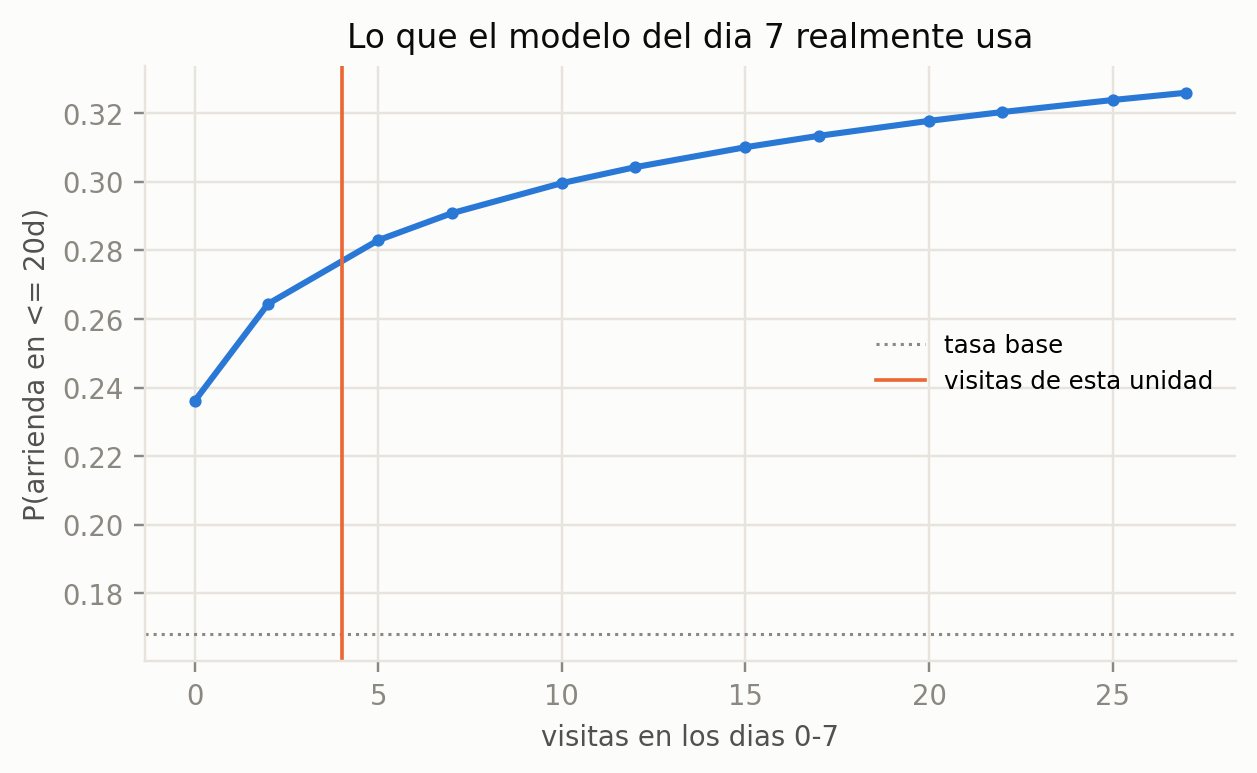

De 0 a 27 visitas, P(arrienda en <= 20d) va de 23.6% a 32.6% (+9.0%).
El signo esperado es POSITIVO: mas interes en la primera semana, mas
probabilidad de colocar. Pero las visitas ANTICIPAN el arriendo, no lo
causan: sirve para priorizar a quien llamar, no para prometer que
forzar visitas acorta el tiempo.


,visitas_d0_7,p_rapido_20d,dias_p50
0,0.000,0.236,45.680
1,2.000,0.264,39.779
2,5.000,0.283,36.455
3,7.000,0.291,35.158
4,10.000,0.300,33.776
5,12.000,0.304,33.073
6,15.000,0.310,32.219
7,17.000,0.313,31.745
8,20.000,0.318,31.135
9,22.000,0.320,30.780



La palanca que se perdio con el ML: el precio


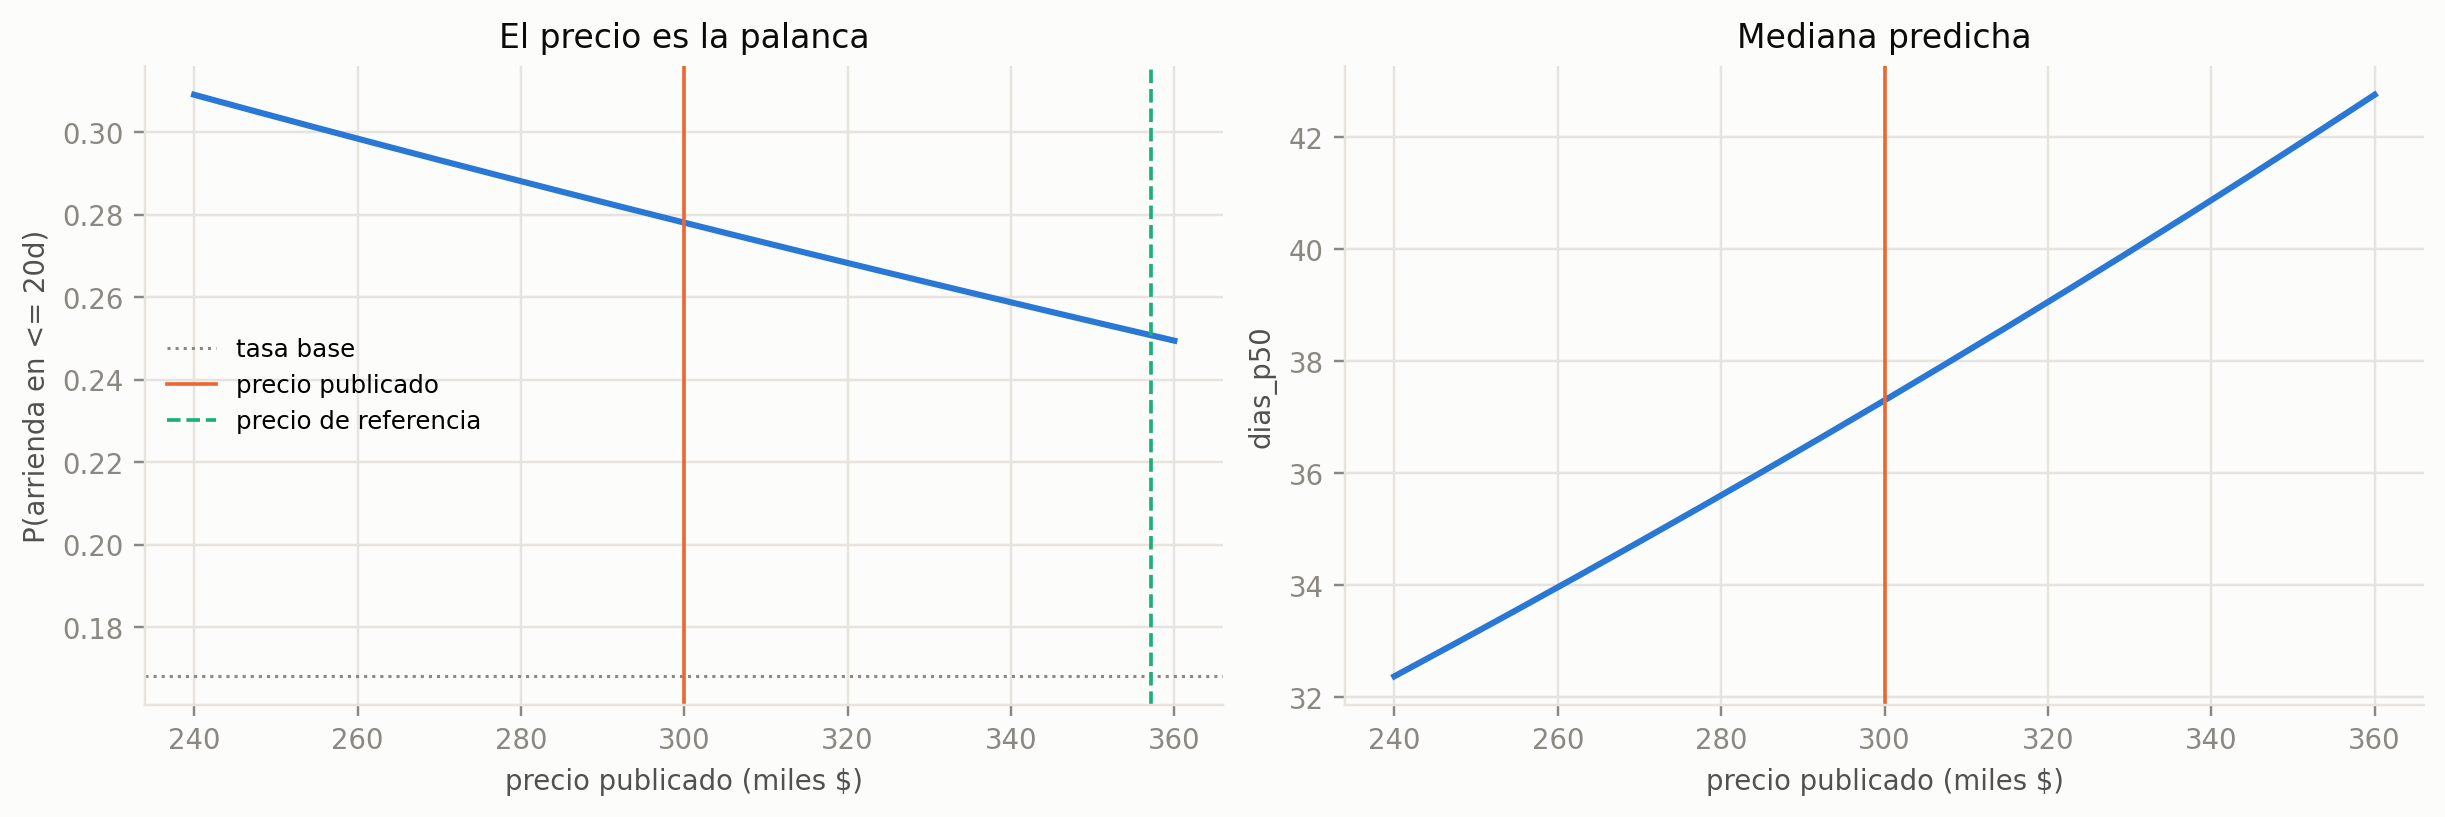

Del -20% al +20%: P(arrienda en <= 20d) cambia -6.0% y la mediana de dias +32%.
Pendiente local: -0.15 puntos porcentuales de probabilidad de arriendo por cada 1% de precio.
El signo esperado es NEGATIVO: publicar mas caro baja la probabilidad de
colocar dentro del horizonte. Y es una COTA INFERIOR en magnitud, porque
la endogeneidad del precio atenua la pendiente hacia cero.


,precio,cambio,gap,p_rapido_20d,dias_p50
0,"240,000.000",-0.200,-0.397,0.309,32.369
4,"270,000.000",-0.100,-0.280,0.293,34.775
8,"300,000.000",0.000,-0.174,0.278,37.301
12,"330,000.000",0.100,-0.079,0.264,39.960
16,"360,000.000",0.200,0.008,0.249,42.764


In [111]:
# ==========================================================================
#  EDITA ESTO. Todo campo que borres o dejes en None se completa con la
#  mediana (o la moda) del entrenamiento, y el reporte te dice cuales fueron.
# ==========================================================================
UNIDAD_NUEVA = {
    # --- DEMANDA DE LA PRIMERA SEMANA -------------------------------------
    # El modelo que gano es el del dia 7: estas tres variables aportan +0,094
    # de AUC, mas que todo el resto junto. Si van vacias, la prediccion es la
    # de una unidad promedio y el reporte te lo va a decir.
    "d0_7_visitas":      None,
    "d0_7_leads":        None,
    "d0_7_reservas":     None,

    # --- precio y ubicacion ------------------------------------------------
    "precio_oferta":     300_000,      # $ mensuales publicados
    "comuna":            "Santiago",
    "barrio":            "Bulnes",     # si el edificio es nuevo, el barrio lo respalda
    "sector_provincia":  "Santiago - Centro",
    "grupo_edificio":    "Paseo Bulnes",   # el nombre exacto que trae la base
    "nombre_tipologia":  "1D1B",

    # --- atributos de la unidad --------------------------------------------
    "m2_utiles":         38,
    "dormitorios":       1,
    "banos":             1,
    "estudio":           0,            # 1 si es estudio
    "piso":              8,            # None o 0 si no se sabe
    "acepta_mascotas":   1,
    "ggcc":              55_000,       # gastos comunes
    "dias_habilitacion": None,         # dias entre creacion y publicacion

    # --- contexto -----------------------------------------------------------
    "mes_lpa":           None,         # None = mes actual
    "owner_type":        None,
}

reporte = puntuar_unidad(UNIDAD_NUEVA)

print("\nDe donde salio cada dato:")
display(reporte["procedencia"])

print("\nLo que mas pesa: la demanda de la primera semana")
tabla_demanda = curva_demanda(UNIDAD_NUEVA)
if tabla_demanda is not None:
    display(tabla_demanda.round(4))

print("\nLa palanca que se perdio con el ML: el precio")
tabla_precio = curva_precio(UNIDAD_NUEVA)
display(tabla_precio.iloc[::4].round(4))

# Para comparar varios escenarios de una vez, descomenta:
# display(puntuar_varias([
#     {**UNIDAD_NUEVA, "etiqueta": "publicado",  "precio_oferta": 420_000},
#     {**UNIDAD_NUEVA, "etiqueta": "-5%",        "precio_oferta": 399_000},
#     {**UNIDAD_NUEVA, "etiqueta": "-10%",       "precio_oferta": 378_000},
# ]).round(4))
